# Cervical Cancer Risk Prediction — CSIS 260 Final Project

**Dataset:** UCI Cervical Cancer Risk Factors Dataset  
**Target variable:** Biopsy  

**Project overview:** Build and evaluate machine-learning models that predict biopsy outcome from patient risk factors. Because the positive class (cancer) is rare, **recall and F1-score** are prioritised over accuracy alone.


## 1. Imports

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from IPython.display import display

from sklearn.model_selection import (
    train_test_split, GridSearchCV, RandomizedSearchCV,
    StratifiedKFold, cross_val_score, learning_curve
)
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, fbeta_score,
    confusion_matrix, classification_report,
    roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score
)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (9, 5)
print('Libraries imported.')


Libraries imported.


## 2. Data Loading and Initial Inspection

We load the dataset and immediately convert ? to NaN so that missing values are handled correctly by scikit-learn.


In [48]:
# Load — tries local file first, then Colab upload, then UCI URL
local_csv = Path('risk_factors_cervical_cancer.csv')
uci_url   = ('https://archive.ics.uci.edu/ml/machine-learning-databases'
              '/00383/risk_factors_cervical_cancer.csv')

if local_csv.exists():
    df_raw = pd.read_csv(local_csv, na_values='?')
    print(f'Loaded local file.')
else:
    try:
        from google.colab import files
        uploaded = files.upload()
        df_raw = pd.read_csv(list(uploaded.keys())[0], na_values='?')
        print('Loaded from Colab upload.')
    except Exception:
        df_raw = pd.read_csv(uci_url, na_values='?')
        print('Loaded from UCI URL.')

print(f'Shape: {df_raw.shape[0]} rows x {df_raw.shape[1]} columns')
display(df_raw.head())


Loaded local file.
Shape: 858 rows x 36 columns


,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,...,STDs: Time since first diagnosis,STDs: Time since last diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy
0,18,4.0,15.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
1,15,1.0,14.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
2,34,1.0,NaN,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
3,52,5.0,16.0,4.0,1.0,37.0,37.0,1.0,3.0,0.0,...,NaN,NaN,1,0,1,0,0,0,0,0
4,46,3.0,21.0,4.0,0.0,0.0,0.0,1.0,15.0,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0


In [49]:
# Data types and missing-value summary
df_raw.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 858 entries, 0 to 857
Data columns (total 36 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Age                                 858 non-null    int64  
 1   Number of sexual partners           832 non-null    float64
 2   First sexual intercourse            851 non-null    float64
 3   Num of pregnancies                  802 non-null    float64
 4   Smokes                              845 non-null    float64
 5   Smokes (years)                      845 non-null    float64
 6   Smokes (packs/year)                 845 non-null    float64
 7   Hormonal Contraceptives             750 non-null    float64
 8   Hormonal Contraceptives (years)     750 non-null    float64
 9   IUD                                 741 non-null    float64
 10  IUD (years)                         741 non-null    float64
 11  STDs                                753 non-n

In [50]:
# Statistical summary
display(df_raw.describe().T.round(3))


,count,mean,std,min,25%,50%,75%,max
Age,858.0,26.821,8.498,13.0,20.0,25.0,32.0,84.0
Number of sexual partners,832.0,2.528,1.668,1.0,2.0,2.0,3.0,28.0
First sexual intercourse,851.0,16.995,2.803,10.0,15.0,17.0,18.0,32.0
Num of pregnancies,802.0,2.276,1.447,0.0,1.0,2.0,3.0,11.0
Smokes,845.0,0.146,0.353,0.0,0.0,0.0,0.0,1.0
Smokes (years),845.0,1.220,4.089,0.0,0.0,0.0,0.0,37.0
Smokes (packs/year),845.0,0.453,2.227,0.0,0.0,0.0,0.0,37.0
Hormonal Contraceptives,750.0,0.641,0.480,0.0,0.0,1.0,1.0,1.0
Hormonal Contraceptives (years),750.0,2.256,3.764,0.0,0.0,0.5,3.0,30.0
IUD,741.0,0.112,0.316,0.0,0.0,0.0,0.0,1.0


In [51]:
# Count duplicate rows before any cleaning
n_dupes = int(df_raw.duplicated().sum())
print(f'Duplicate rows found: {n_dupes}')


Duplicate rows found: 23


## 3. Data Cleaning and Preparation

Cleaning decisions:
1. **Remove duplicate rows** — the same patient record must not appear in both train and test.
2. **Drop high-missingness columns** (>80% missing) — STDs: Time since first diagnosis and STDs: Time since last diagnosis carry almost no stable information.
3. **Drop leaky diagnostic columns** — Hinselmann, Schiller, and Citology are other clinical test results, not patient risk-factor inputs. Keeping them would create target leakage.
4. **Convert remaining columns to numeric** — ensures all values are parsed correctly after NaN substitution.


In [52]:
df = df_raw.copy()

# 1. Remove duplicates
rows_before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f'Duplicates removed: {rows_before - len(df)}  |  Rows remaining: {len(df)}')

# 2. Drop high-missingness columns (>80% missing)
HIGH_MISS = ['STDs: Time since first diagnosis', 'STDs: Time since last diagnosis']
df.drop(columns=[c for c in HIGH_MISS if c in df.columns], inplace=True)
print(f'Dropped high-miss columns: {HIGH_MISS}')

# 3. Drop leaky diagnostic-test columns
LEAKY = ['Hinselmann', 'Schiller', 'Citology']
df.drop(columns=[c for c in LEAKY if c in df.columns], inplace=True)
print(f'Dropped leaky columns: {LEAKY}')

# 4. Ensure all columns are numeric
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(f'\nFinal shape: {df.shape}')


Duplicates removed: 23  |  Rows remaining: 835
Dropped high-miss columns: ['STDs: Time since first diagnosis', 'STDs: Time since last diagnosis']
Dropped leaky columns: ['Hinselmann', 'Schiller', 'Citology']

Final shape: (835, 31)


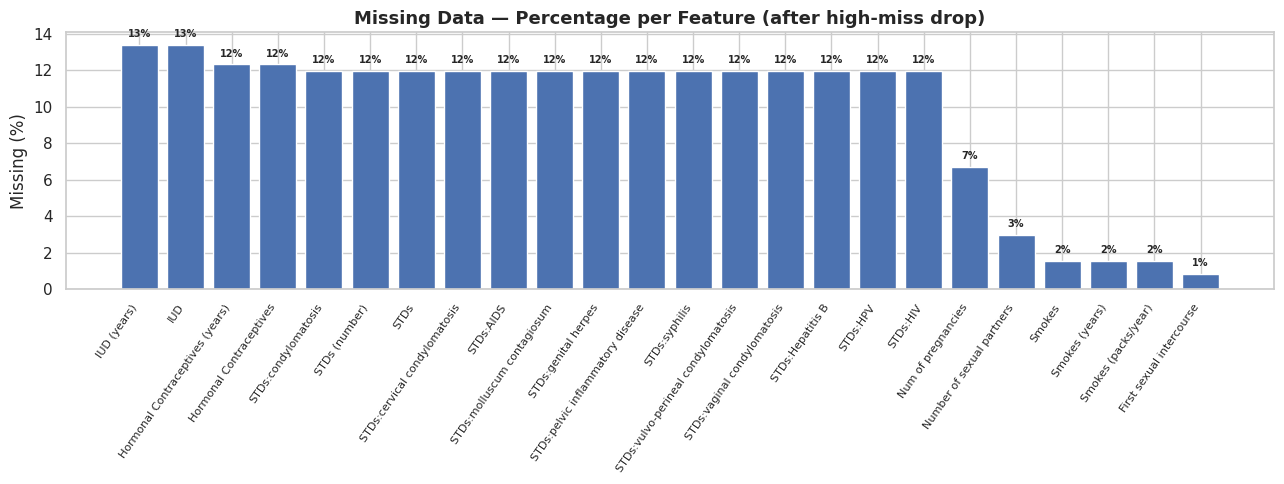

In [53]:
# Missing-value audit
miss_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
miss_nonzero = miss_pct[miss_pct > 0]

plt.figure(figsize=(13, 5))
colors = ['#C44E52' if v > 30 else '#4C72B0' for v in miss_nonzero.values]
bars = plt.bar(miss_nonzero.index, miss_nonzero.values, color=colors, edgecolor='white')
plt.title('Missing Data — Percentage per Feature (after high-miss drop)', fontsize=13, fontweight='bold')
plt.ylabel('Missing (%)')
plt.xticks(rotation=55, ha='right', fontsize=8)
for bar, v in zip(bars, miss_nonzero.values):
    plt.text(bar.get_x() + bar.get_width()/2, v + 0.3, f'{v:.0f}%',
             ha='center', va='bottom', fontsize=7, fontweight='bold')
plt.tight_layout()
plt.show()


### 3.1 Feature Engineering

Three domain-motivated interaction features are created before splitting so that they are available to all models:

- **Smoking_Intensity** — smoking status × years smoked (captures cumulative exposure).
- **Smoking_Per_Year** — normalised smoking rate (avoids zero-division with +1 smoothing).
- **Sexual_Risk_Index** — number of sexual partners × STD status (joint risk proxy).


In [54]:
df['Smoking_Intensity'] = df['Smokes'] * df['Smokes (years)']
df['Smoking_Per_Year']  = df['Smokes'] / (df['Smokes (years)'] + 1)
df['Sexual_Risk_Index'] = df['Number of sexual partners'] * df['STDs']

print('Engineered features added. Final column count:', df.shape[1])
display(df.describe().T.round(3))


Engineered features added. Final column count: 34


,count,mean,std,min,25%,50%,75%,max
Age,835.0,27.024,8.483,13.0,21.0,26.0,32.0,84.000
Number of sexual partners,810.0,2.552,1.677,1.0,2.0,2.0,3.0,28.000
First sexual intercourse,828.0,17.021,2.817,10.0,15.0,17.0,18.0,32.000
Num of pregnancies,779.0,2.304,1.456,0.0,1.0,2.0,3.0,11.000
Smokes,822.0,0.150,0.357,0.0,0.0,0.0,0.0,1.000
Smokes (years),822.0,1.254,4.141,0.0,0.0,0.0,0.0,37.000
Smokes (packs/year),822.0,0.466,2.256,0.0,0.0,0.0,0.0,37.000
Hormonal Contraceptives,732.0,0.652,0.477,0.0,0.0,1.0,1.0,1.000
Hormonal Contraceptives (years),732.0,2.303,3.794,0.0,0.0,0.5,3.0,30.000
IUD,723.0,0.115,0.319,0.0,0.0,0.0,0.0,1.000


## 4. Exploratory Data Analysis (EDA)

EDA answers three questions:
1. How imbalanced is the target?
2. Which features differ most between biopsy-positive and biopsy-negative patients?
3. Which features are correlated with each other (multicollinearity)?

These findings directly motivate: median imputation, SMOTE, StandardScaler, and the PCA experiment.


In [55]:
TARGET = 'Biopsy'

# Class distribution
counts = df[TARGET].value_counts().sort_index()
pct    = (df[TARGET].value_counts(normalize=True) * 100).sort_index()
class_df = pd.DataFrame({'Count': counts, 'Percentage (%)': pct.round(2)})
class_df.index = ['Negative (0)', 'Positive (1)']
print('Class Balance:')
display(class_df)
print(f'Imbalance ratio: {counts[0]/counts[1]:.1f} : 1')


Class Balance:


,Count,Percentage (%)
Negative (0),781,93.53
Positive (1),54,6.47


Imbalance ratio: 14.5 : 1


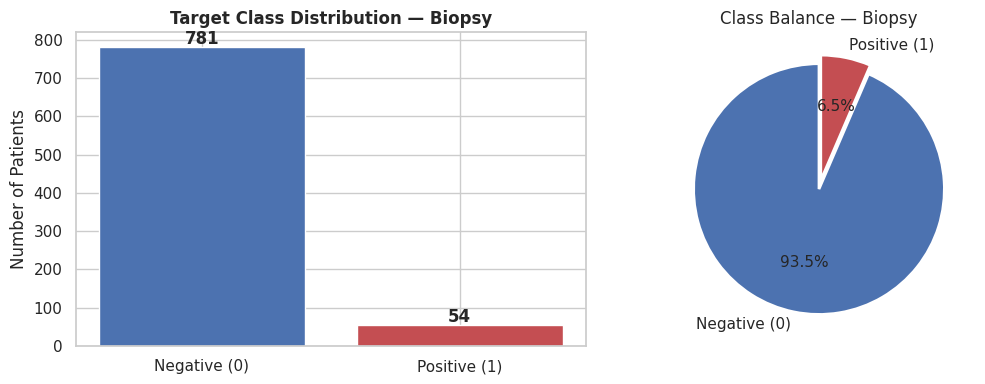

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

class_labels = ['Negative (0)', 'Positive (1)']
bar_colors   = ['#4C72B0', '#C44E52']

axes[0].bar(class_labels, counts.values, color=bar_colors, edgecolor='white')
axes[0].set_title('Target Class Distribution — Biopsy', fontweight='bold')
axes[0].set_ylabel('Number of Patients')
for i, v in enumerate(counts.values):
    axes[0].annotate(str(int(v)), (i, v + max(counts.values)*0.01), ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=class_labels, colors=bar_colors,
            explode=[0, 0.07], autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 11}, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class Balance — Biopsy')
plt.tight_layout()
plt.show()


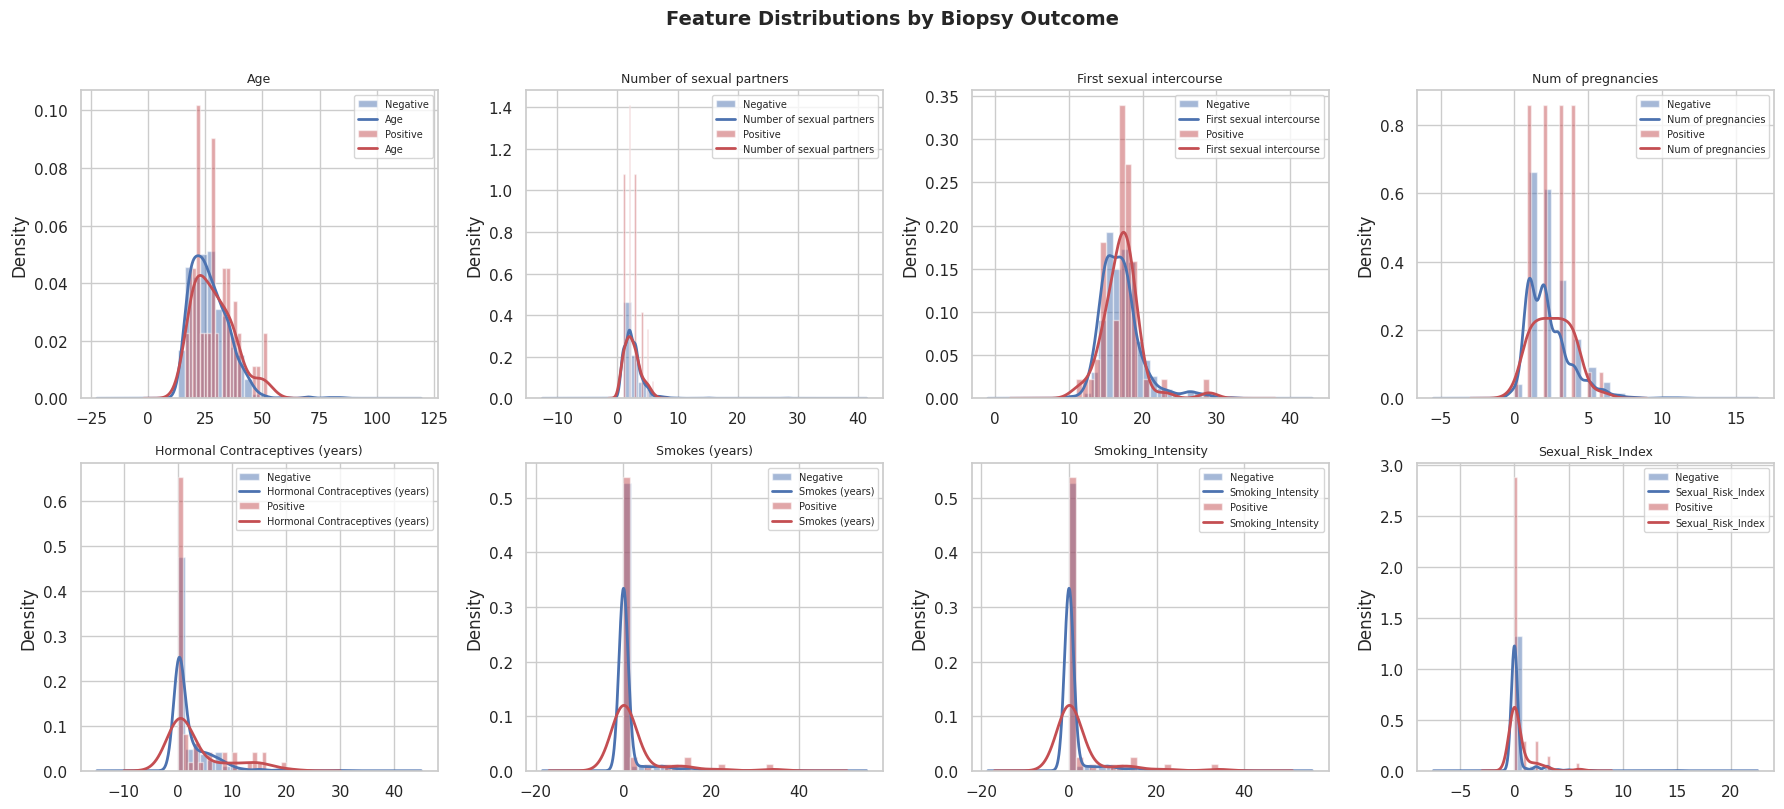

In [57]:
# Histograms of key continuous features split by Biopsy outcome
plot_cols = ['Age', 'Number of sexual partners', 'First sexual intercourse',
             'Num of pregnancies', 'Hormonal Contraceptives (years)',
             'Smokes (years)', 'Smoking_Intensity', 'Sexual_Risk_Index']
plot_cols = [c for c in plot_cols if c in df.columns]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes_flat = axes.flatten()
for i, col in enumerate(plot_cols):
    for bval, color, label in [(0,'#4C72B0','Negative'), (1,'#C44E52','Positive')]:
        subset = df[df[TARGET]==bval][col].dropna()
        axes_flat[i].hist(subset, bins=22, alpha=0.5, color=color,
                          density=True, edgecolor='white', label=label)
        subset.plot.kde(ax=axes_flat[i], color=color, linewidth=2)
    axes_flat[i].set_title(col, fontsize=9)
    axes_flat[i].legend(fontsize=7)
for j in range(i+1, len(axes_flat)):
    axes_flat[j].set_visible(False)
fig.suptitle('Feature Distributions by Biopsy Outcome', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


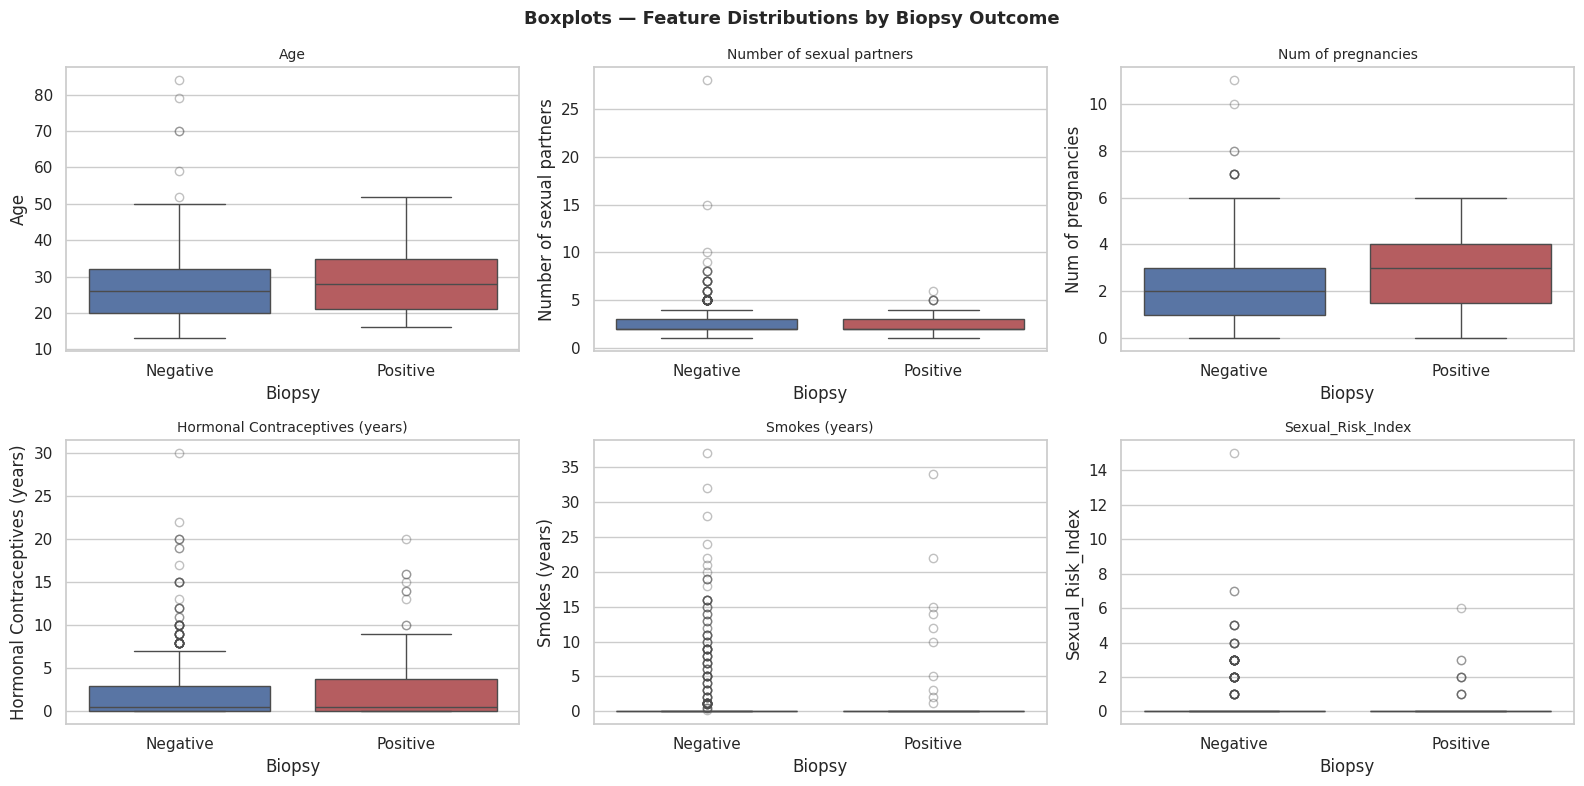

In [58]:
# Boxplots by Biopsy outcome
box_cols = ['Age', 'Number of sexual partners', 'Num of pregnancies',
            'Hormonal Contraceptives (years)', 'Smokes (years)', 'Sexual_Risk_Index']
box_cols = [c for c in box_cols if c in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes_flat = axes.flatten()
for i, col in enumerate(box_cols):
    sns.boxplot(x=TARGET, y=col, data=df, hue=TARGET,
                palette={0:'#4C72B0', 1:'#C44E52'},
                ax=axes_flat[i], legend=False,
                flierprops={'alpha':0.35})
    axes_flat[i].set_xticklabels(['Negative', 'Positive'])
    axes_flat[i].set_title(col, fontsize=10)
for j in range(i+1, len(axes_flat)):
    axes_flat[j].set_visible(False)
fig.suptitle('Boxplots — Feature Distributions by Biopsy Outcome', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


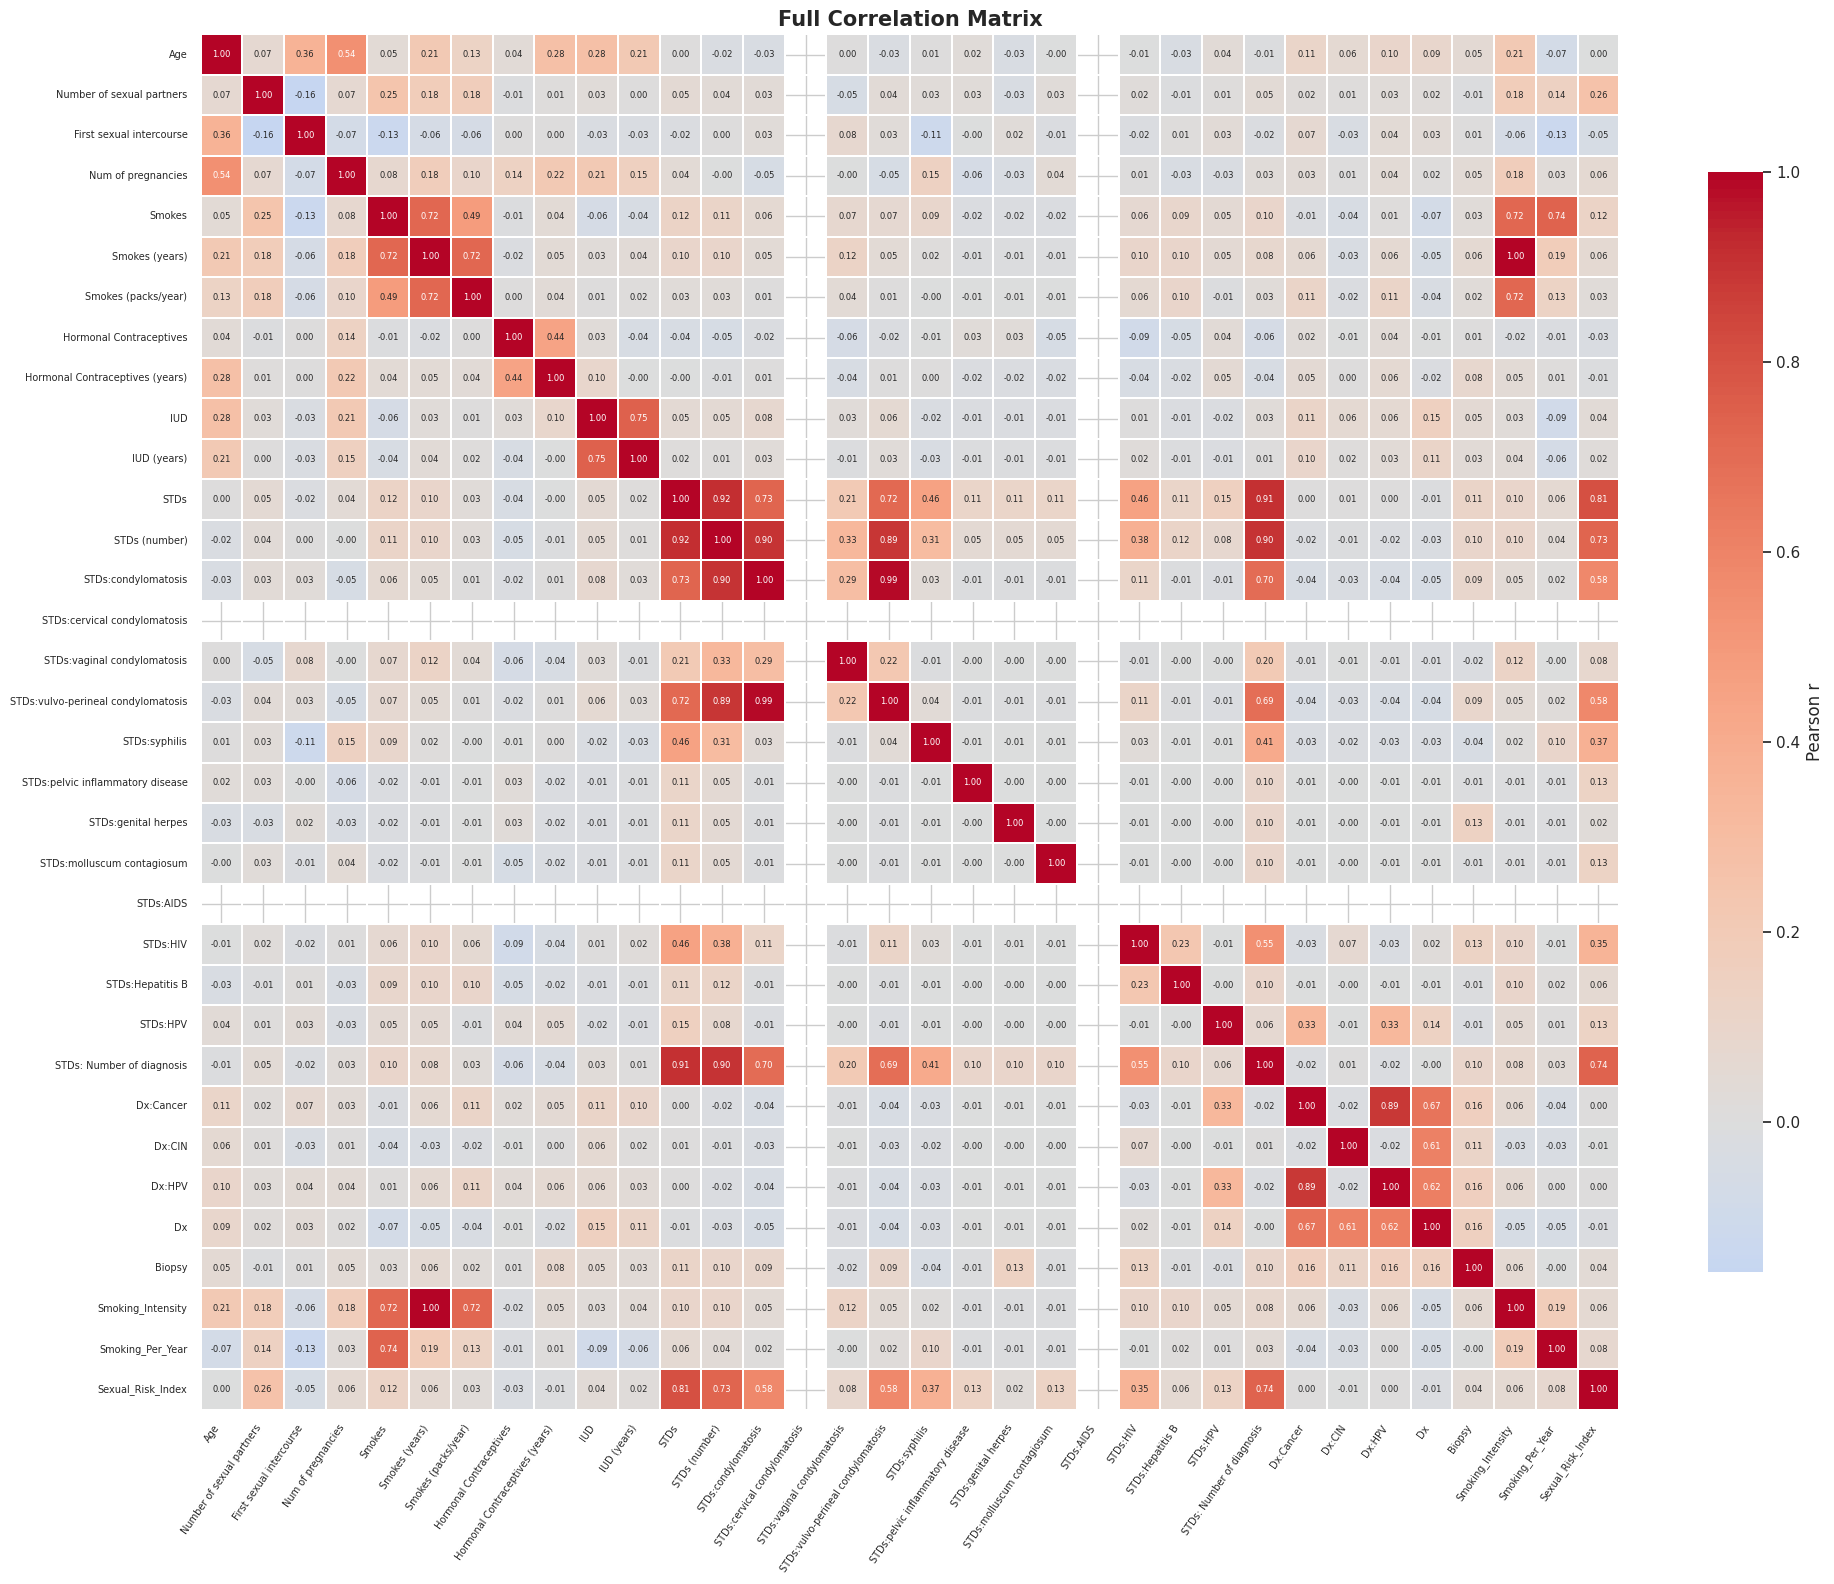

In [59]:
# Full correlation heatmap
corr_matrix = df.corr()
plt.figure(figsize=(20, 16))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0,
            linewidths=0.3, linecolor='white',
            annot=True, fmt='.2f', annot_kws={'size': 6},
            cbar_kws={'shrink': 0.8, 'label': 'Pearson r'})
plt.title('Full Correlation Matrix', fontsize=15, fontweight='bold')
plt.xticks(rotation=55, ha='right', fontsize=7)
plt.yticks(fontsize=7)
plt.tight_layout()
plt.show()


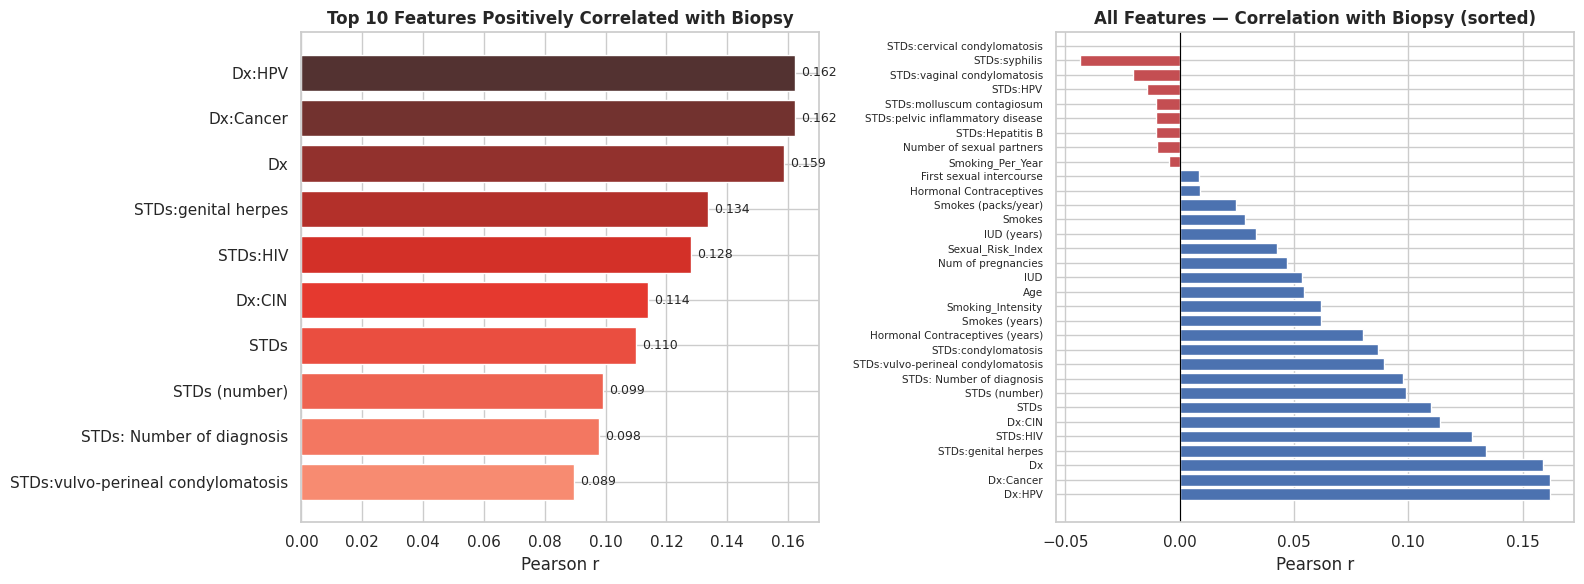

Top 15 features correlated with Biopsy:
Dx:HPV                                0.1621
Dx:Cancer                             0.1621
Dx                                    0.1588
STDs:genital herpes                   0.1338
STDs:HIV                              0.1279
Dx:CIN                                0.1140
STDs                                  0.1098
STDs (number)                         0.0990
STDs: Number of diagnosis             0.0978
STDs:vulvo-perineal condylomatosis    0.0895
STDs:condylomatosis                   0.0869
Hormonal Contraceptives (years)       0.0801
Smokes (years)                        0.0620
Smoking_Intensity                     0.0620
Age                                   0.0544


In [60]:
# Correlation with Biopsy target
target_corr = corr_matrix[TARGET].drop(TARGET).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top10 = target_corr.head(10)
axes[0].barh(top10.index[::-1], top10.values[::-1],
             color=sns.color_palette('Reds_d', 10), edgecolor='white')
axes[0].set_title('Top 10 Features Positively Correlated with Biopsy', fontweight='bold')
axes[0].set_xlabel('Pearson r')
for i, v in enumerate(top10.values[::-1]):
    axes[0].text(v+0.002, i, f'{v:.3f}', va='center', fontsize=9)

c_colors = ['#C44E52' if v < 0 else '#4C72B0' for v in target_corr.values]
axes[1].barh(target_corr.index, target_corr.values, color=c_colors, edgecolor='white')
axes[1].set_title('All Features — Correlation with Biopsy (sorted)', fontweight='bold')
axes[1].set_xlabel('Pearson r')
axes[1].axvline(0, color='black', lw=0.8)
axes[1].tick_params(axis='y', labelsize=7.5)
plt.tight_layout()
plt.show()

print('Top 15 features correlated with Biopsy:')
print(target_corr.head(15).round(4).to_string())


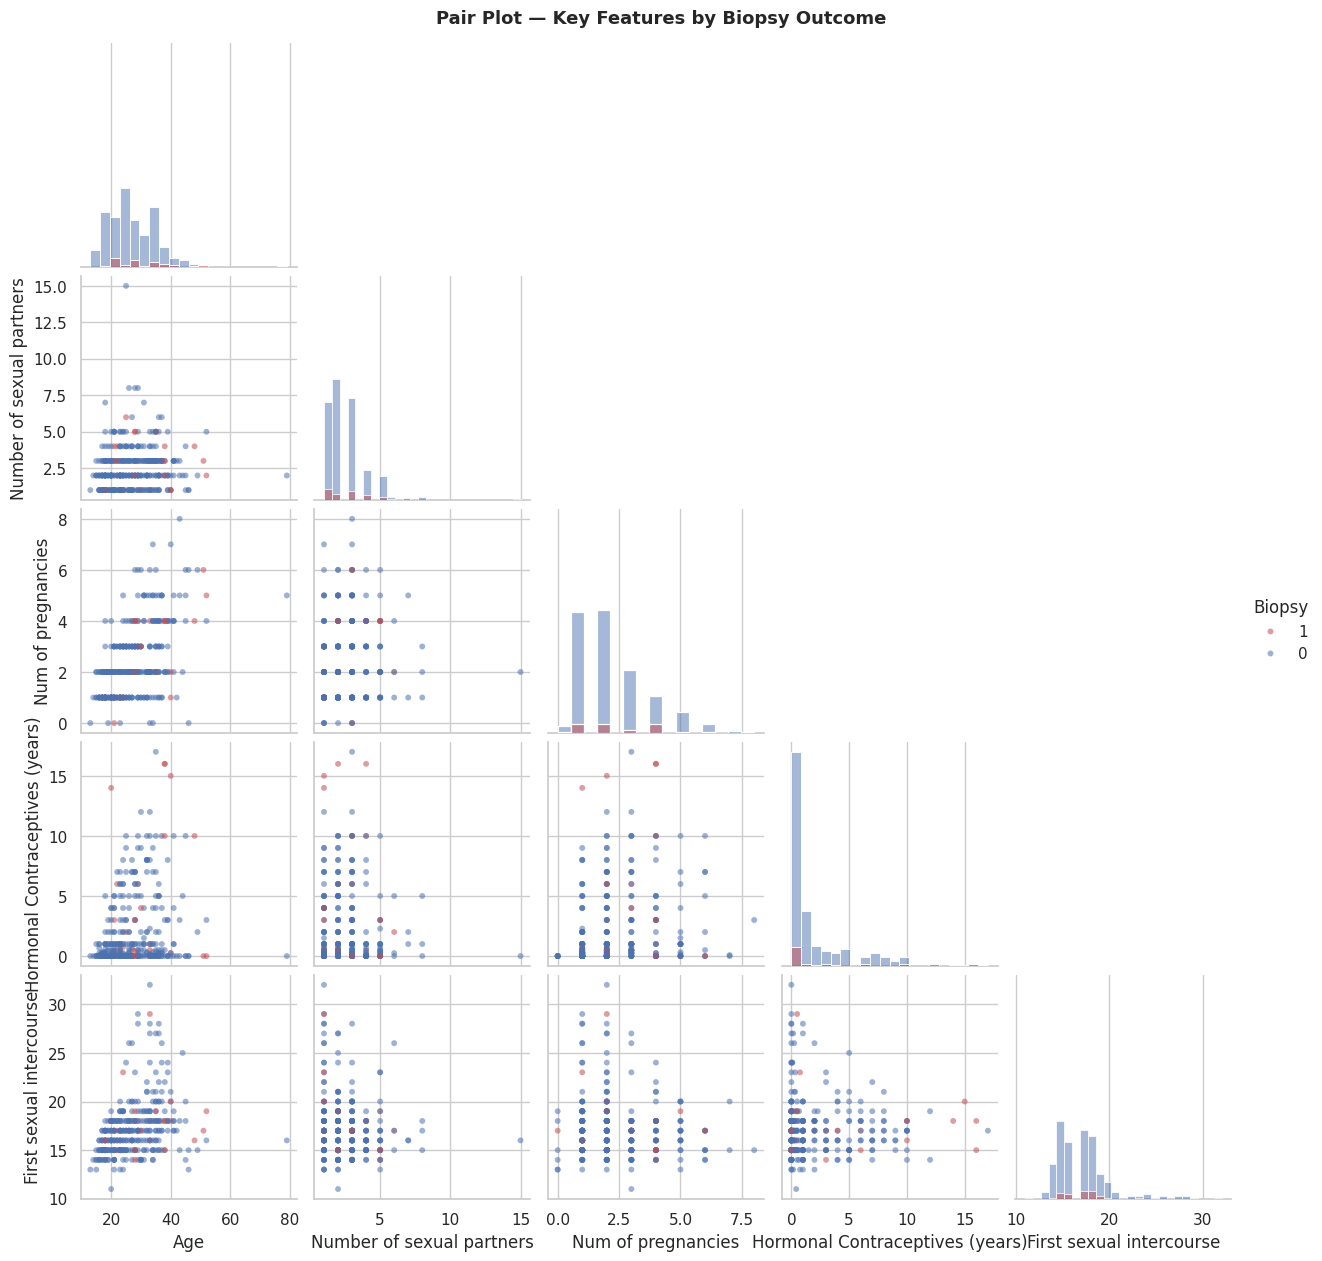

In [61]:
# Compact pair plot
pair_cols = ['Age', 'Number of sexual partners', 'Num of pregnancies',
             'Hormonal Contraceptives (years)', 'First sexual intercourse', TARGET]
pair_cols = [c for c in pair_cols if c in df.columns]
df_pair = df[pair_cols].dropna().copy()
if len(df_pair) > 350:
    df_pair = df_pair.sample(n=350, random_state=42)
df_pair[TARGET] = df_pair[TARGET].astype(str)

g = sns.pairplot(df_pair, hue=TARGET,
                 palette={'0':'#4C72B0','1':'#C44E52'},
                 plot_kws={'alpha':0.55, 's':18, 'edgecolor':'none'},
                 diag_kind='hist', corner=True)
g.figure.suptitle('Pair Plot — Key Features by Biopsy Outcome',
                   y=1.01, fontsize=13, fontweight='bold')
plt.show()


## 5. Train / Validation / Test Split

Three-way split:
- **Train (64%)** — used for model fitting inside cross-validation.
- **Validation (16%)** — used for threshold tuning after hyperparameter search.
- **Test (20%)** — touched only once at the very end for final evaluation.

Stratification preserves the class ratio in every subset.


In [62]:
X = df.drop(TARGET, axis=1)
y = df[TARGET]

# First split off test set (20%)
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

# Then split train/val from the remaining 80% (val = 20% of 80% = 16% overall)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.20, stratify=y_trainval, random_state=42
)

print(f'Train : {X_train.shape[0]} rows')
print(f'Val   : {X_val.shape[0]} rows')
print(f'Test  : {X_test.shape[0]} rows')
print(f'\nPositive rate — Train: {y_train.mean():.3f} | Val: {y_val.mean():.3f} | Test: {y_test.mean():.3f}')


Train : 534 rows
Val   : 134 rows
Test  : 167 rows

Positive rate — Train: 0.064 | Val: 0.067 | Test: 0.066


## 6. Preprocessing and Class-Imbalance Handling

**Imputation → Scaling → SMOTE** applied only to the training data.  
Validation and test sets are only transformed (not fitted), preserving the real class ratio for honest evaluation.

SMOTE is applied **after** scaling and **only on training data** to avoid leaking synthetic minority-class information into evaluation.


In [63]:
# Impute missing values with median (robust to skewed medical data)
imputer = SimpleImputer(strategy='median')
X_train_imp = imputer.fit_transform(X_train)
X_val_imp   = imputer.transform(X_val)
X_test_imp  = imputer.transform(X_test)

# Scale features
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_imp)
X_val_sc   = scaler.transform(X_val_imp)
X_test_sc  = scaler.transform(X_test_imp)

# SMOTE on training data only
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_sc, y_train)

print('Class counts before SMOTE:', dict(zip(*np.unique(y_train, return_counts=True))))
print('Class counts after  SMOTE:', dict(zip(*np.unique(y_train_bal, return_counts=True))))


Class counts before SMOTE: {np.int64(0): np.int64(500), np.int64(1): np.int64(34)}
Class counts after  SMOTE: {np.int64(0): np.int64(500), np.int64(1): np.int64(500)}


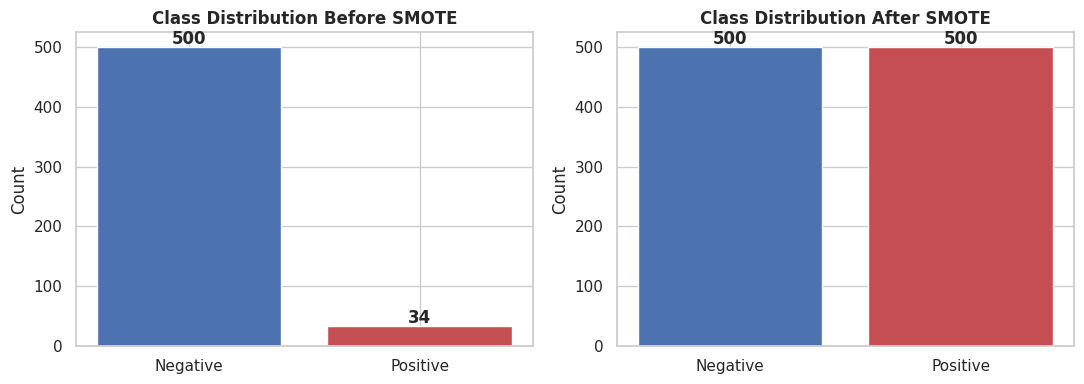

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, data, title in [
    (axes[0], y_train, 'Class Distribution Before SMOTE'),
    (axes[1], y_train_bal, 'Class Distribution After SMOTE')
]:
    vals, cnts = np.unique(data, return_counts=True)
    ax.bar(['Negative','Positive'], cnts, color=['#4C72B0','#C44E52'], edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Count')
    for i, c in enumerate(cnts):
        ax.text(i, c + max(cnts)*0.01, str(int(c)), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()


## 7. Regularisation: L1 vs L2 Logistic Regression

L1 drives irrelevant feature coefficients to exactly zero (feature selection effect). L2 shrinks all coefficients but keeps them non-zero. We compare both to choose the better starting-point logistic model.


In [65]:
l1_model = LogisticRegression(penalty='l1', solver='liblinear', random_state=42)
l2_model = LogisticRegression(penalty='l2', solver='liblinear', random_state=42)

l1_model.fit(X_train_bal, y_train_bal)
l2_model.fit(X_train_bal, y_train_bal)

l1_pred = l1_model.predict(X_test_sc)
l2_pred = l2_model.predict(X_test_sc)

reg_comparison = pd.DataFrame({
    'Model'    : ['L1', 'L2'],
    'Accuracy' : [accuracy_score(y_test, l1_pred), accuracy_score(y_test, l2_pred)],
    'Precision': [precision_score(y_test, l1_pred, zero_division=0),
                  precision_score(y_test, l2_pred, zero_division=0)],
    'Recall'   : [recall_score(y_test, l1_pred), recall_score(y_test, l2_pred)],
    'F1'       : [f1_score(y_test, l1_pred), f1_score(y_test, l2_pred)]
})
display(reg_comparison)


,Model,Accuracy,Precision,Recall,F1
0,L1,0.730539,0.075,0.272727,0.117647
1,L2,0.718563,0.050,0.181818,0.078431


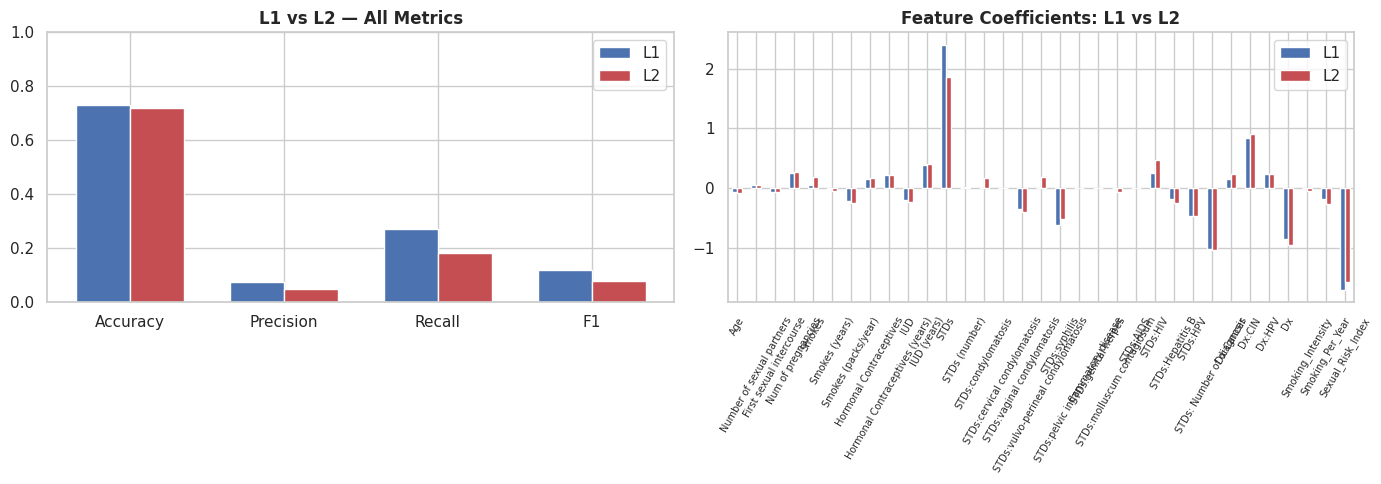

Best baseline logistic (by F1): L1


In [66]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
x = np.arange(len(metrics))
w = 0.35
axes[0].bar(x - w/2, reg_comparison.iloc[0][metrics], w, label='L1', color='#4C72B0', edgecolor='white')
axes[0].bar(x + w/2, reg_comparison.iloc[1][metrics], w, label='L2', color='#C44E52', edgecolor='white')
axes[0].set_xticks(x); axes[0].set_xticklabels(metrics)
axes[0].set_ylim(0, 1); axes[0].set_title('L1 vs L2 — All Metrics', fontweight='bold')
axes[0].legend()

l1_coef = pd.Series(l1_model.coef_[0], index=X.columns)
l2_coef = pd.Series(l2_model.coef_[0], index=X.columns)
coef_df = pd.DataFrame({'L1': l1_coef, 'L2': l2_coef})
coef_df.plot(kind='bar', ax=axes[1], color=['#4C72B0','#C44E52'], edgecolor='white')
axes[1].set_title('Feature Coefficients: L1 vs L2', fontweight='bold')
axes[1].tick_params(axis='x', rotation=60, labelsize=7)
plt.tight_layout()
plt.show()

best_logistic_baseline = l1_model if f1_score(y_test, l1_pred) >= f1_score(y_test, l2_pred) else l2_model
print('Best baseline logistic (by F1):', 'L1' if best_logistic_baseline is l1_model else 'L2')


## 8. Baseline Model Training

Three models trained with default / light settings to establish a midterm-level baseline before hyperparameter tuning.


Validation-selected baseline thresholds:
- Logistic baseline: 0.50
- SVM baseline: 0.49
- Random Forest baseline: 0.44

Logistic (baseline)
------------------------------------------
Threshold: 0.50
Accuracy : 0.7305  Precision: 0.0750
Recall   : 0.2727  F1       : 0.1176
ROC-AUC  : 0.4073  Avg Prec : 0.0613

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.76      0.84       156
           1       0.07      0.27      0.12        11

    accuracy                           0.73       167
   macro avg       0.51      0.52      0.48       167
weighted avg       0.88      0.73      0.79       167



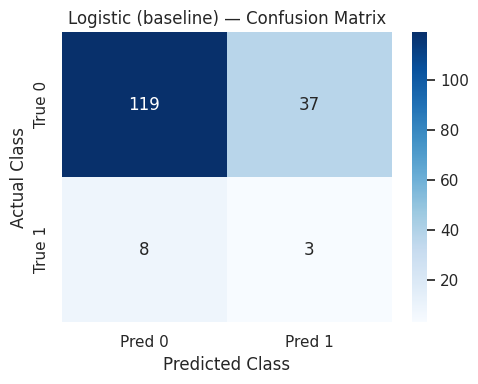

What the visual shows:
- True positives (correct positive biopsy predictions): 3
- False negatives (missed positive biopsy cases): 8
- False positives (negative cases predicted as positive): 37
- Summary: precision=0.0750, recall=0.2727, F1=0.1176

SVM (baseline)
------------------------------------------
Threshold: 0.49
Accuracy : 0.7006  Precision: 0.0851
Recall   : 0.3636  F1       : 0.1379
ROC-AUC  : 0.5728  Avg Prec : 0.0954

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.72      0.82       156
           1       0.09      0.36      0.14        11

    accuracy                           0.70       167
   macro avg       0.51      0.54      0.48       167
weighted avg       0.89      0.70      0.77       167



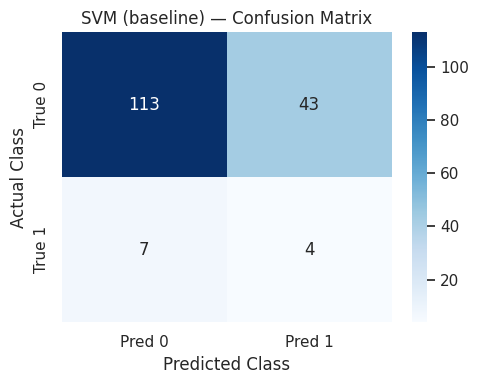

What the visual shows:
- True positives (correct positive biopsy predictions): 4
- False negatives (missed positive biopsy cases): 7
- False positives (negative cases predicted as positive): 43
- Summary: precision=0.0851, recall=0.3636, F1=0.1379

Random Forest (baseline)
------------------------------------------
Threshold: 0.44
Accuracy : 0.7126  Precision: 0.0488
Recall   : 0.1818  F1       : 0.0769
ROC-AUC  : 0.5000  Avg Prec : 0.0676

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.75      0.83       156
           1       0.05      0.18      0.08        11

    accuracy                           0.71       167
   macro avg       0.49      0.47      0.45       167
weighted avg       0.87      0.71      0.78       167



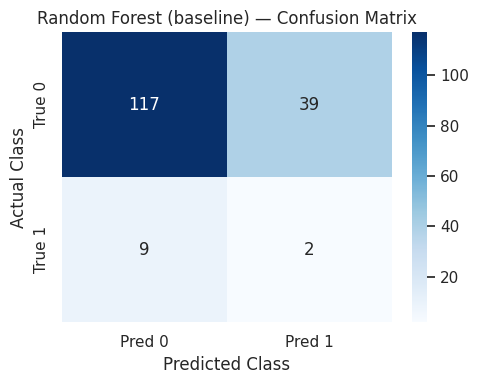

What the visual shows:
- True positives (correct positive biopsy predictions): 2
- False negatives (missed positive biopsy cases): 9
- False positives (negative cases predicted as positive): 39
- Summary: precision=0.0488, recall=0.1818, F1=0.0769


In [67]:
# Baseline model training and evaluation
# ------------------------------------------------------------
# We train the three baseline models: Logistic Regression, SVM, and Random Forest.
# These baseline results give us a comparison point before tuning, PCA, and advanced threshold tuning.

svm_baseline = SVC(kernel='rbf', probability=True, random_state=42)

rf_baseline  = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    min_samples_leaf=3,
    class_weight='balanced',
    random_state=42
)

svm_baseline.fit(X_train_bal, y_train_bal)
rf_baseline.fit(X_train_bal, y_train_bal)


def validation_threshold_search(model, X_val, y_val, beta=2.0, max_threshold=0.50):
    """
    Select a decision threshold using validation data only.

    We cap the threshold at 0.50 because a higher threshold is usually too conservative
    for a rare positive medical class and can easily lead to zero predicted positives.
    F2 is used because it gives recall more weight than precision.
    """
    y_prob_val = model.predict_proba(X_val)[:, 1]
    thresholds = np.linspace(0.05, max_threshold, 46)

    rows = []
    for t in thresholds:
        y_pred_t = (y_prob_val >= t).astype(int)
        rows.append({
            'threshold': t,
            'precision': precision_score(y_val, y_pred_t, zero_division=0),
            'recall': recall_score(y_val, y_pred_t, zero_division=0),
            'f1': f1_score(y_val, y_pred_t, zero_division=0),
            'f2': fbeta_score(y_val, y_pred_t, beta=beta, zero_division=0),
            'predicted_positives': int(y_pred_t.sum())
        })

    sweep_df = pd.DataFrame(rows)

    # Keep only useful thresholds that predict at least one positive case on validation.
    candidates = sweep_df[sweep_df['predicted_positives'] > 0].copy()
    if candidates.empty:
        candidates = sweep_df.copy()

    best_row = candidates.sort_values(
        ['f2', 'f1', 'recall', 'threshold'],
        ascending=[False, False, False, True]
    ).iloc[0]

    return float(best_row['threshold']), sweep_df


def evaluate_model(name, model, X_eval, y_eval, threshold=0.5):
    """
    Evaluate a model using a chosen threshold and show both numbers and a visual confusion matrix.

    The confusion matrix is important because it shows exactly where the model is making mistakes:
    true negatives, false positives, false negatives, and true positives.
    """
    y_prob = model.predict_proba(X_eval)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    acc  = accuracy_score(y_eval, y_pred)
    prec = precision_score(y_eval, y_pred, zero_division=0)
    rec  = recall_score(y_eval, y_pred, zero_division=0)
    f1   = f1_score(y_eval, y_pred, zero_division=0)
    auc  = roc_auc_score(y_eval, y_prob)
    ap   = average_precision_score(y_eval, y_prob)

    print(f'\n{name}')
    print('-' * 42)
    print(f'Threshold: {threshold:.2f}')
    print(f'Accuracy : {acc:.4f}  Precision: {prec:.4f}')
    print(f'Recall   : {rec:.4f}  F1       : {f1:.4f}')
    print(f'ROC-AUC  : {auc:.4f}  Avg Prec : {ap:.4f}')
    print('\nClassification Report:')
    print(classification_report(y_eval, y_pred, zero_division=0))

    cm = confusion_matrix(y_eval, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Pred 0','Pred 1'],
                yticklabels=['True 0','True 1'])
    plt.title(f'{name} — Confusion Matrix')
    plt.xlabel('Predicted Class')
    plt.ylabel('Actual Class')
    plt.tight_layout(); plt.show()

    tn, fp, fn, tp = cm.ravel()
    print('What the visual shows:')
    print(f'- True positives (correct positive biopsy predictions): {tp}')
    print(f'- False negatives (missed positive biopsy cases): {fn}')
    print(f'- False positives (negative cases predicted as positive): {fp}')
    print(f'- Summary: precision={prec:.4f}, recall={rec:.4f}, F1={f1:.4f}')

    return dict(Model=name, Accuracy=acc, Precision=prec, Recall=rec, F1=f1, AUC=auc, AP=ap,
                Threshold=threshold, y_prob=y_prob, y_pred=y_pred)


# Validation-based baseline thresholds.
# Logistic uses the selected L1/L2 baseline model from the regularisation comparison.
base_lr_t, base_lr_sweep = validation_threshold_search(best_logistic_baseline, X_val_sc, y_val, beta=2.0)
base_svm_t, base_svm_sweep = validation_threshold_search(svm_baseline, X_val_sc, y_val, beta=2.0)
base_rf_t, base_rf_sweep = validation_threshold_search(rf_baseline, X_val_sc, y_val, beta=2.0)

print('Validation-selected baseline thresholds:')
print(f'- Logistic baseline: {base_lr_t:.2f}')
print(f'- SVM baseline: {base_svm_t:.2f}')
print(f'- Random Forest baseline: {base_rf_t:.2f}')

baseline_results = []
baseline_results.append(evaluate_model('Logistic (baseline)', best_logistic_baseline, X_test_sc, y_test, threshold=base_lr_t))
baseline_results.append(evaluate_model('SVM (baseline)',      svm_baseline,           X_test_sc, y_test, threshold=base_svm_t))
baseline_results.append(evaluate_model('Random Forest (baseline)', rf_baseline,       X_test_sc, y_test, threshold=base_rf_t))


### Baseline Metrics Visual Summary

This block turns the baseline numbers into a visual comparison. The goal is to quickly see whether any baseline model is still failing on the minority positive class after the threshold fix.

- **What we are doing:** comparing accuracy, precision, recall, F1, AUC, and average precision for the three baseline models.
- **Why we are doing it:** the table alone can hide problems, while the chart makes zero or weak metrics obvious.
- **What the result should show:** Random Forest should no longer have precision/recall/F1 equal to zero because its threshold is selected on validation data instead of blindly using 0.50.


,Accuracy,Precision,Recall,F1,AUC,AP,Threshold
Model,,,,,,,
Logistic (baseline),0.7305,0.0750,0.2727,0.1176,0.4073,0.0613,0.50
SVM (baseline),0.7006,0.0851,0.3636,0.1379,0.5728,0.0954,0.49
Random Forest (baseline),0.7126,0.0488,0.1818,0.0769,0.5000,0.0676,0.44


<Figure size 1300x600 with 0 Axes>

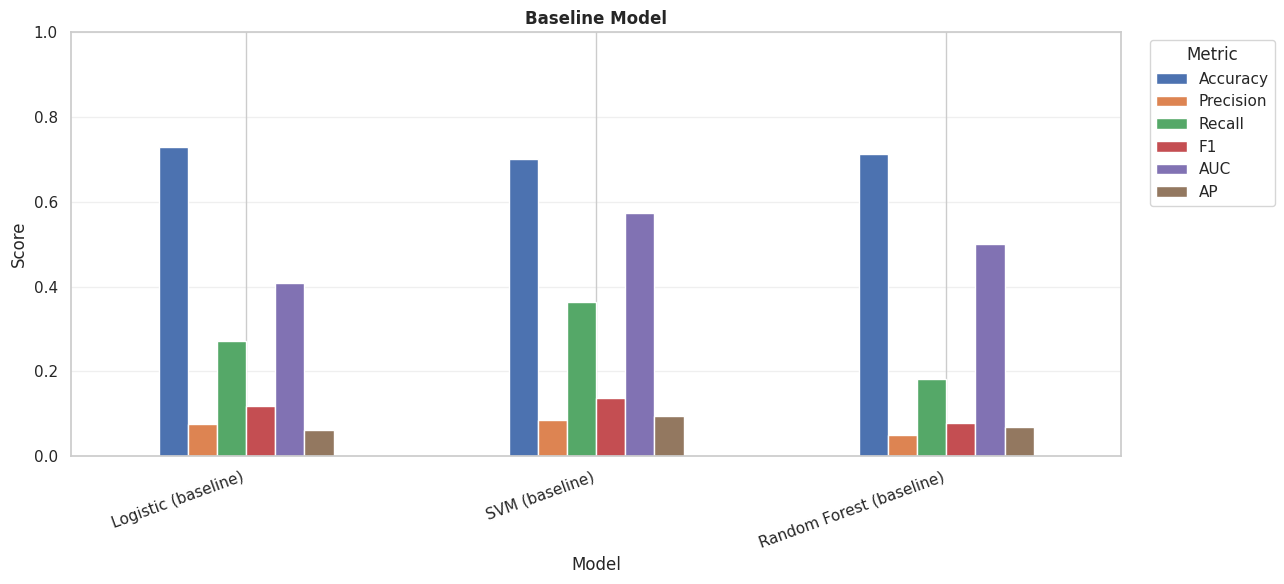

Baseline summary:
- Logistic (baseline): threshold=0.50, precision=0.0750, recall=0.2727, F1=0.1176 → no zero precision/recall/F1 issue
- SVM (baseline): threshold=0.49, precision=0.0851, recall=0.3636, F1=0.1379 → no zero precision/recall/F1 issue
- Random Forest (baseline): threshold=0.44, precision=0.0488, recall=0.1818, F1=0.0769 → no zero precision/recall/F1 issue


In [68]:
# Visual comparison of baseline model performance
# ------------------------------------------------------------
# We convert the baseline_results list into a clean table and grouped bar chart.
# Why we are doing it:
# This makes it easier to compare all baseline models visually instead of reading only raw numbers.

baseline_df = pd.DataFrame([{k:v for k,v in r.items() if k not in ('y_prob','y_pred')}
                            for r in baseline_results])
display(baseline_df.set_index('Model').round(4))

metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC', 'AP']
baseline_plot_df = baseline_df.set_index('Model')[metrics_to_plot]

plt.figure(figsize=(13, 6))
baseline_plot_df.plot(kind='bar', figsize=(13, 6), edgecolor='white')
plt.title('Baseline Model', fontweight='bold')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=20, ha='right')
plt.legend(title='Metric', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

zero_metric_check = baseline_df[['Precision','Recall','F1']].eq(0).any(axis=1)
print('Baseline summary:')
for _, row in baseline_df.iterrows():
    status = 'needs review' if zero_metric_check.loc[_] else 'no zero precision/recall/F1 issue'
    print(f"- {row['Model']}: threshold={row['Threshold']:.2f}, "
          f"precision={row['Precision']:.4f}, recall={row['Recall']:.4f}, F1={row['F1']:.4f} → {status}")


In [69]:
baseline_df = pd.DataFrame([{k:v for k,v in r.items() if k not in ('y_prob','y_pred')}
                            for r in baseline_results])
print('Baseline results:')
display(baseline_df.set_index('Model').round(4))


Baseline results:


,Accuracy,Precision,Recall,F1,AUC,AP,Threshold
Model,,,,,,,
Logistic (baseline),0.7305,0.0750,0.2727,0.1176,0.4073,0.0613,0.50
SVM (baseline),0.7006,0.0851,0.3636,0.1379,0.5728,0.0954,0.49
Random Forest (baseline),0.7126,0.0488,0.1818,0.0769,0.5000,0.0676,0.44


## 9. Hyperparameter Tuning

All three model families are tuned using **GridSearchCV** with 5-fold stratified CV scored on F1.  
Tuning is done on SMOTE-balanced training data. Validation and test data are never seen during search.


In [70]:
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# --- Logistic Regression ---
lr_params = {
    'C'      : [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver' : ['liblinear']
}
lr_grid = GridSearchCV(LogisticRegression(random_state=42, max_iter=1000),
                       lr_params, cv=cv5, scoring='f1', n_jobs=-1)
lr_grid.fit(X_train_bal, y_train_bal)
best_lr = lr_grid.best_estimator_
print('Best LR params :', lr_grid.best_params_)
print('Best LR CV F1  :', round(lr_grid.best_score_, 4))


Best LR params : {'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}
Best LR CV F1  : 0.5825


In [71]:
# --- SVM ---
svm_params = {
    'C'     : [0.1, 1, 10, 100],
    'gamma' : ['scale', 0.1, 0.01],
    'kernel': ['rbf']
}
svm_grid = GridSearchCV(SVC(probability=True, random_state=42),
                        svm_params, cv=cv5, scoring='f1', n_jobs=-1)
svm_grid.fit(X_train_bal, y_train_bal)
best_svm = svm_grid.best_estimator_
print('Best SVM params:', svm_grid.best_params_)
print('Best SVM CV F1 :', round(svm_grid.best_score_, 4))


Best SVM params: {'C': 100, 'gamma': 0.1, 'kernel': 'rbf'}
Best SVM CV F1 : 0.8994


In [72]:
# --- Random Forest ---

rf_params = {
    'n_estimators'     : [200, 300, 500],
    'max_depth'        : [3, 4, 5, 6],
    'min_samples_split': [10, 20, 30],
    'min_samples_leaf' : [4, 6, 8, 10],
    'max_features'     : ['sqrt', 'log2'],
    'class_weight'     : ['balanced']
}
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42),
                       rf_params, cv=cv5, scoring='f1', n_jobs=-1)
rf_grid.fit(X_train_bal, y_train_bal)
best_rf = rf_grid.best_estimator_
print('Best RF params :', rf_grid.best_params_)
print('Best RF CV F1  :', round(rf_grid.best_score_, 4))


Best RF params : {'class_weight': 'balanced', 'max_depth': 6, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 200}
Best RF CV F1  : 0.8943


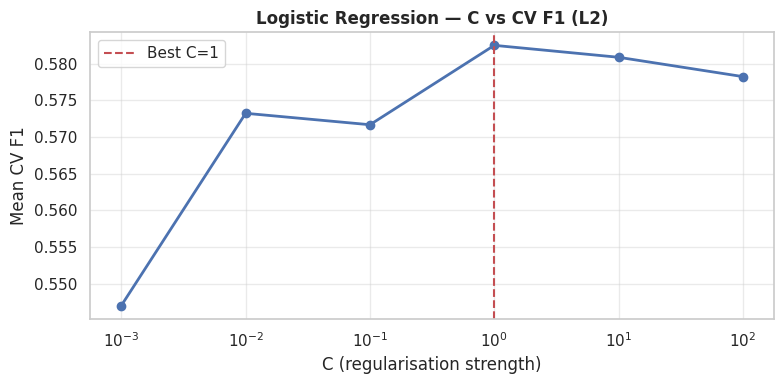

In [73]:
# Hyperparameter sensitivity: LR C vs CV F1
lr_results_df = pd.DataFrame(lr_grid.cv_results_)
lr_l2 = lr_results_df[lr_results_df['param_penalty']=='l2'].groupby('param_C')['mean_test_score'].mean()

plt.figure(figsize=(8, 4))
plt.semilogx(lr_l2.index.astype(float), lr_l2.values, marker='o', color='#4C72B0', linewidth=2)
plt.axvline(lr_grid.best_params_['C'], color='#C44E52', ls='--', label=f"Best C={lr_grid.best_params_['C']}")
plt.title('Logistic Regression — C vs CV F1 (L2)', fontweight='bold')
plt.xlabel('C (regularisation strength)'); plt.ylabel('Mean CV F1')
plt.legend(); plt.grid(alpha=0.4); plt.tight_layout(); plt.show()


- This line plot evaluates Logistic Regression performance for dufferent values of C.
- Best performance occurs at C=1.


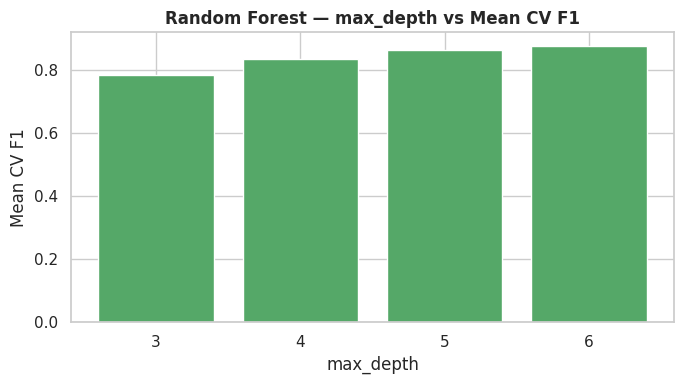

In [74]:
# Hyperparameter sensitivity: RF max_depth vs CV F1
rf_results_df = pd.DataFrame(rf_grid.cv_results_)

depth_scores = {}
for row in rf_results_df.itertuples():
    d = row.param_max_depth if row.param_max_depth is not None else 'None'
    depth_scores.setdefault(d, []).append(row.mean_test_score)
depth_mean = {k: np.mean(v) for k, v in depth_scores.items()}

plt.figure(figsize=(7, 4))
plt.bar([str(k) for k in depth_mean.keys()], depth_mean.values(),
        color='#55A868', edgecolor='white')
plt.title('Random Forest — max_depth vs Mean CV F1', fontweight='bold')
plt.xlabel('max_depth'); plt.ylabel('Mean CV F1')
plt.tight_layout(); plt.show()


- Performance improves as the depth increases from 3 to 6.
- RF with deeper trees performed better, with depth 6 giving the strongest overall balance between precision and recall.

## 10. PCA Analysis

We test whether PCA dimensionality reduction improves model performance. PCA is applied **after scaling and SMOTE** on the training data. We retain 95% of explained variance.

PCA is useful when features are correlated (reducing noise), but can hurt interpretability. Both variants are evaluated fairly using the **same tuned hyperparameters**.


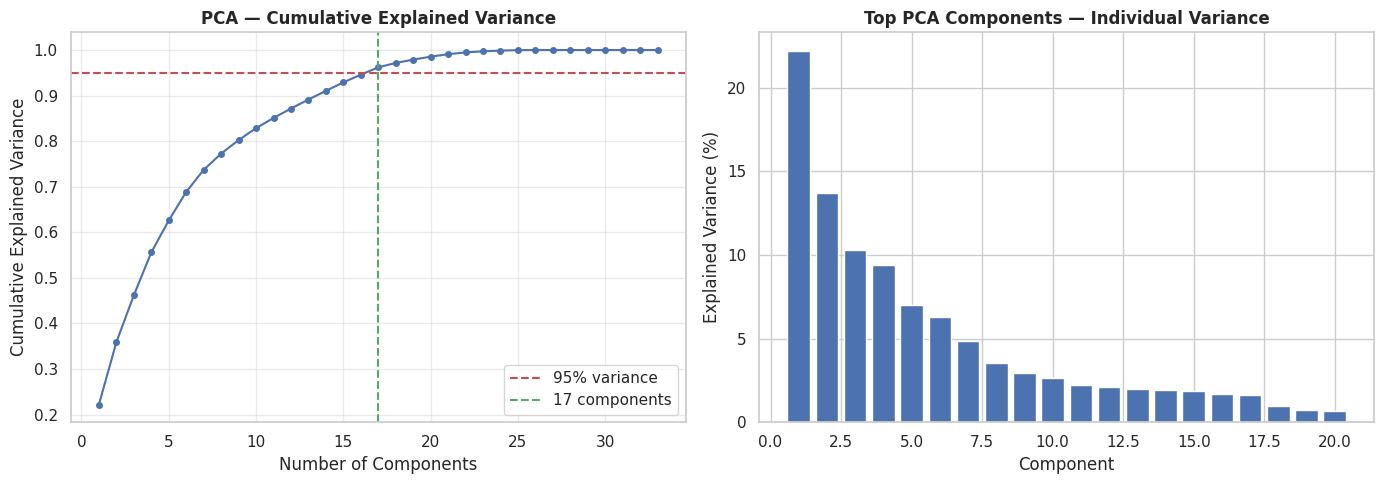

Components needed for 95% variance: 17


In [75]:
# Explained variance plot
pca_full = PCA()
pca_full.fit(X_train_bal)

cum_var = np.cumsum(pca_full.explained_variance_ratio_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cumulative variance
axes[0].plot(
    range(1, len(cum_var) + 1),
    cum_var,
    marker='o',
    markersize=4,
    color='#4C72B0'
)

axes[0].axhline(0.95, color='#C44E52', ls='--', label='95% variance')

n95 = int(np.argmax(cum_var >= 0.95)) + 1

axes[0].axvline(n95, color='#55A868', ls='--', label=f'{n95} components')

axes[0].set_xlabel('Number of Components')
axes[0].set_ylabel('Cumulative Explained Variance')
axes[0].set_title('PCA — Cumulative Explained Variance', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.4)

# Individual variance
n_components = min(20, len(pca_full.explained_variance_ratio_))

axes[1].bar(
    range(1, n_components + 1),
    pca_full.explained_variance_ratio_[:n_components] * 100,
    color='#4C72B0',
    edgecolor='white'
)

axes[1].set_xlabel('Component')
axes[1].set_ylabel('Explained Variance (%)')
axes[1].set_title('Top PCA Components — Individual Variance', fontweight='bold')

plt.tight_layout()
plt.show()

print(f'Components needed for 95% variance: {n95}')


- PCA reduces dimensionality while keeping most important information.
- Most important informtion in the originak dataset can be compressed into 17 dimensions.

In [76]:
# Apply PCA
pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_bal)
X_val_pca   = pca.transform(X_val_sc)
X_test_pca  = pca.transform(X_test_sc)

print(f'Original shape : {X_train_bal.shape}')
print(f'PCA shape      : {X_train_pca.shape}')


Original shape : (1000, 33)
PCA shape      : (1000, 17)


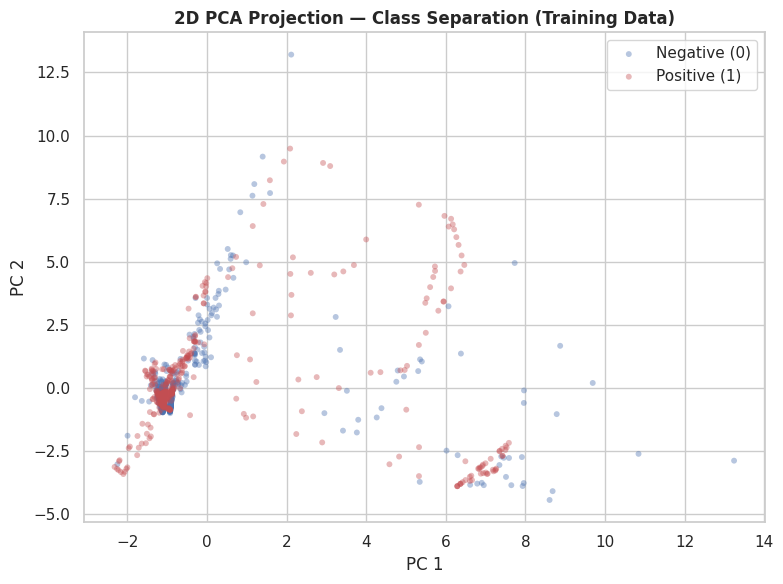

In [77]:
# 2D PCA scatter — class separation
plt.figure(figsize=(8, 6))
for bval, color, label in [(0,'#4C72B0','Negative (0)'), (1,'#C44E52','Positive (1)')]:
    mask = y_train_bal == bval
    plt.scatter(X_train_pca[mask, 0], X_train_pca[mask, 1],
                alpha=0.4, s=18, color=color, label=label, edgecolors='none')
plt.xlabel('PC 1'); plt.ylabel('PC 2')
plt.title('2D PCA Projection — Class Separation (Training Data)', fontweight='bold')
plt.legend(); plt.tight_layout(); plt.show()


- PCA successfully captured meaningfull structure.
- The first two principal components contain useful info but not enough for perfect separation.

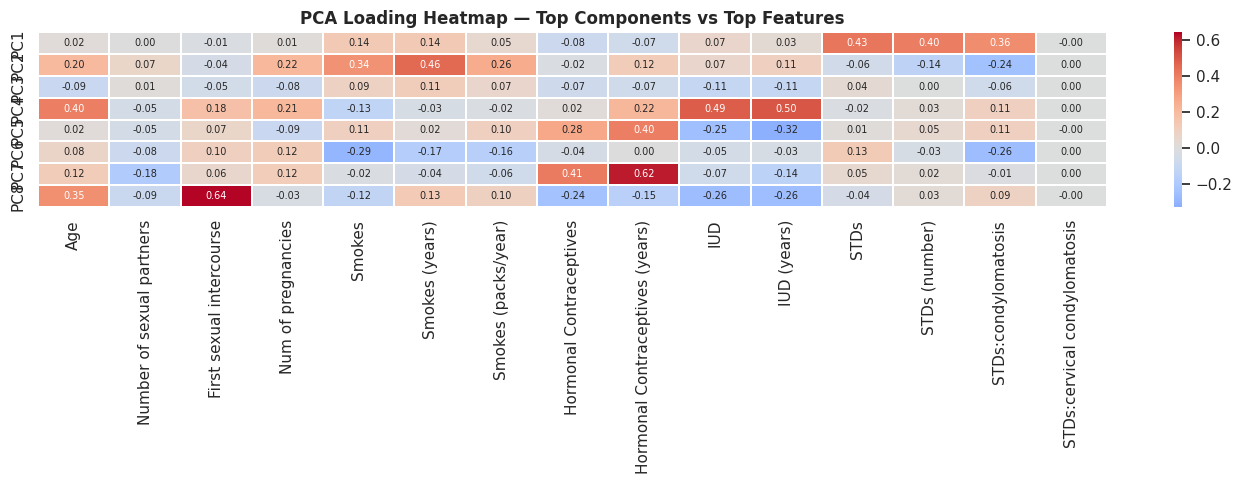

In [78]:
# PCA loading heatmap (top components vs top features)
feature_names = list(X.columns)
n_show_comp   = min(8, pca.n_components_)
n_show_feat   = min(15, len(feature_names))
loadings = pd.DataFrame(
    pca.components_[:n_show_comp, :n_show_feat],
    index=[f'PC{i+1}' for i in range(n_show_comp)],
    columns=feature_names[:n_show_feat]
)
plt.figure(figsize=(14, 5))
sns.heatmap(loadings, cmap='coolwarm', center=0, annot=True, fmt='.2f',
            annot_kws={'size':7}, linewidths=0.3)
plt.title('PCA Loading Heatmap — Top Components vs Top Features', fontweight='bold')
plt.tight_layout(); plt.show()


In [79]:
# Train PCA versions using the SAME tuned hyperparameters
best_lr_pca = LogisticRegression(**{k: v for k, v in lr_grid.best_params_.items()},
                                  random_state=42, max_iter=1000)
best_svm_pca = SVC(C=svm_grid.best_params_['C'],
                   gamma=svm_grid.best_params_['gamma'],
                   kernel='rbf', probability=True, random_state=42)
best_rf_pca  = RandomForestClassifier(**rf_grid.best_params_, random_state=42)

best_lr_pca.fit(X_train_pca, y_train_bal)
best_svm_pca.fit(X_train_pca, y_train_bal)
best_rf_pca.fit(X_train_pca, y_train_bal)
print('PCA models trained with tuned hyperparameters.')


PCA models trained with tuned hyperparameters.


## 11. Threshold Tuning

In [80]:
# Final threshold tuning using validation data only
# ------------------------------------------------------------
# We search across decision thresholds and choose the threshold that gives the best validation F2-score.
# The dataset is imbalanced, so the default 0.50 threshold can miss the rare positive class.
# The printed thresholds tell us how strict each model should be when converting probabilities into class labels.

def tune_threshold(model, X_val, y_val, beta=2.0, max_threshold=0.50):
    y_prob = model.predict_proba(X_val)[:, 1]

    thresholds = np.linspace(0.05, max_threshold, 46)

    rows = []
    for t in thresholds:
        y_pred_t = (y_prob >= t).astype(int)
        rows.append({
            'threshold': t,
            'precision': precision_score(y_val, y_pred_t, zero_division=0),
            'recall': recall_score(y_val, y_pred_t, zero_division=0),
            'f1': f1_score(y_val, y_pred_t, zero_division=0),
            'f2': fbeta_score(y_val, y_pred_t, beta=beta, zero_division=0),
            'predicted_positives': int(y_pred_t.sum())
        })

    sweep_df = pd.DataFrame(rows)

    candidates = sweep_df[sweep_df['predicted_positives'] > 0].copy()
    if candidates.empty:
        candidates = sweep_df.copy()

    best_row = candidates.sort_values(
        ['f2', 'f1', 'recall', 'threshold'],
        ascending=[False, False, False, True]
    ).iloc[0]

    return best_row['threshold'], best_row['f1'], best_row['recall'], best_row['f2'], sweep_df

models_no_pca  = {'Logistic': best_lr,  'SVM': best_svm,  'Random Forest': best_rf}
models_with_pca = {'Logistic+PCA': best_lr_pca, 'SVM+PCA': best_svm_pca, 'RF+PCA': best_rf_pca}

val_data = {
    'Logistic': (X_val_sc,  y_val), 'SVM': (X_val_sc,  y_val), 'Random Forest': (X_val_sc,  y_val),
    'Logistic+PCA': (X_val_pca, y_val), 'SVM+PCA': (X_val_pca, y_val), 'RF+PCA': (X_val_pca, y_val)
}

best_thresholds = {}
threshold_sweeps = {}
all_models_combined = {**models_no_pca, **models_with_pca}

for name, model in all_models_combined.items():
    xv, yv = val_data[name]
    t, f1_val, rec_val, f2_val, sweep_df = tune_threshold(model, xv, yv, beta=2.0, max_threshold=0.50)
    best_thresholds[name] = t
    threshold_sweeps[name] = sweep_df
    print(f'{name:20s}  threshold: {t:.2f}  val recall: {rec_val:.4f}  val F1: {f1_val:.4f}  val F2: {f2_val:.4f}')



Logistic              threshold: 0.50  val recall: 0.5556  val F1: 0.1961  val F2: 0.3205
SVM                   threshold: 0.16  val recall: 0.4444  val F1: 0.1951  val F2: 0.2941
Random Forest         threshold: 0.42  val recall: 0.6667  val F1: 0.2791  val F2: 0.4286
Logistic+PCA          threshold: 0.42  val recall: 0.7778  val F1: 0.1522  val F2: 0.2941
SVM+PCA               threshold: 0.06  val recall: 0.6667  val F1: 0.1818  val F2: 0.3226
RF+PCA                threshold: 0.50  val recall: 0.5556  val F1: 0.2941  val F2: 0.4098


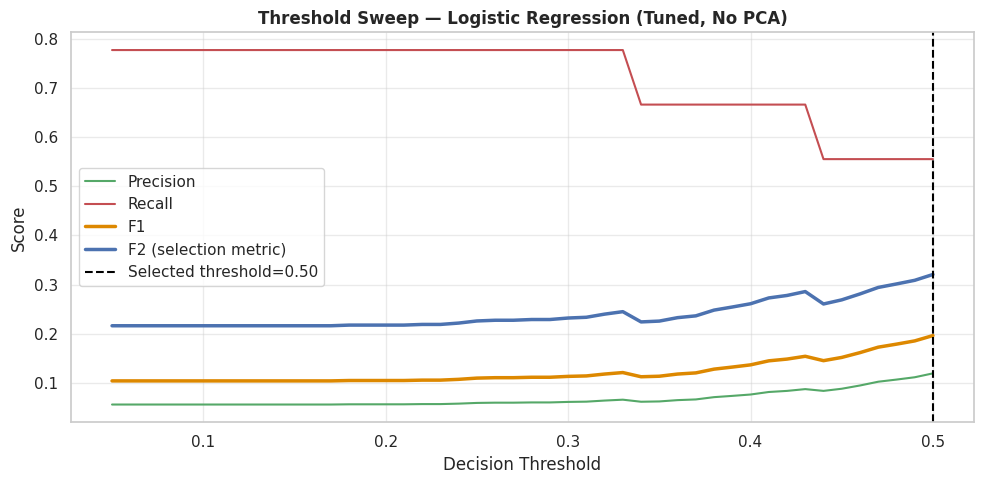

Logistic threshold summary:
- Selected threshold: 0.50
- Validation precision: 0.1190
- Validation recall: 0.5556
- Validation F1: 0.1961
- Validation F2: 0.3205
- The black dashed line marks the threshold used later on the test set.


In [81]:
# Threshold sweep visualisation for Logistic Regression (tuned, no PCA)
# ------------------------------------------------------------
# We plot precision, recall, F1, and F2 across different thresholds for Logistic Regression.
# A lower threshold usually catches more positive cases, increasing recall, while precision may decrease.

logistic_sweep = threshold_sweeps['Logistic']

plt.figure(figsize=(10, 5))
plt.plot(logistic_sweep['threshold'], logistic_sweep['precision'], label='Precision', color='#55A868')
plt.plot(logistic_sweep['threshold'], logistic_sweep['recall'],    label='Recall',    color='#C44E52')
plt.plot(logistic_sweep['threshold'], logistic_sweep['f1'],        label='F1',        color='#DD8800', linewidth=2.5)
plt.plot(logistic_sweep['threshold'], logistic_sweep['f2'],        label='F2 (selection metric)', color='#4C72B0', linewidth=2.5)
best_t = best_thresholds['Logistic']
plt.axvline(best_t, color='black', ls='--', label=f'Selected threshold={best_t:.2f}')
plt.xlabel('Decision Threshold'); plt.ylabel('Score')
plt.title('Threshold Sweep — Logistic Regression (Tuned, No PCA)', fontweight='bold')
plt.legend(); plt.grid(alpha=0.4); plt.tight_layout(); plt.show()

selected_row = logistic_sweep.iloc[(logistic_sweep['threshold'] - best_t).abs().argmin()]
print('Logistic threshold summary:')
print(f"- Selected threshold: {best_t:.2f}")
print(f"- Validation precision: {selected_row['precision']:.4f}")
print(f"- Validation recall: {selected_row['recall']:.4f}")
print(f"- Validation F1: {selected_row['f1']:.4f}")
print(f"- Validation F2: {selected_row['f2']:.4f}")
print('- The black dashed line marks the threshold used later on the test set.')


## 12. Final Model Evaluation on Test Set

- applying the tuned models to unseen test data.
The confusion matrices show whether the model is catching positive biopsy cases or missing them.




Logistic
------------------------------------------
Threshold: 0.50
Accuracy : 0.7186  Precision: 0.0500
Recall   : 0.1818  F1       : 0.0784
ROC-AUC  : 0.3998  Avg Prec : 0.0617

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.76      0.83       156
           1       0.05      0.18      0.08        11

    accuracy                           0.72       167
   macro avg       0.49      0.47      0.46       167
weighted avg       0.87      0.72      0.78       167



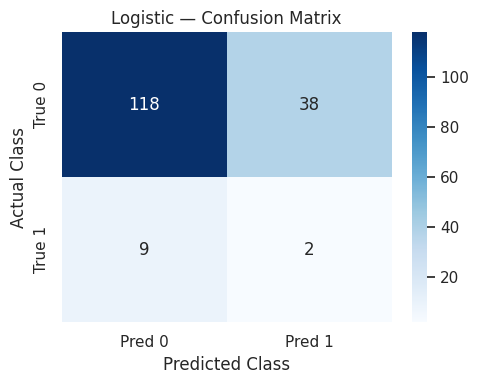

What the visual shows:
- True positives (correct positive biopsy predictions): 2
- False negatives (missed positive biopsy cases): 9
- False positives (negative cases predicted as positive): 38
- Summary: precision=0.0500, recall=0.1818, F1=0.0784

SVM
------------------------------------------
Threshold: 0.16
Accuracy : 0.6886  Precision: 0.0233
Recall   : 0.0909  F1       : 0.0370
ROC-AUC  : 0.4481  Avg Prec : 0.0637

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.73      0.81       156
           1       0.02      0.09      0.04        11

    accuracy                           0.69       167
   macro avg       0.47      0.41      0.43       167
weighted avg       0.86      0.69      0.76       167



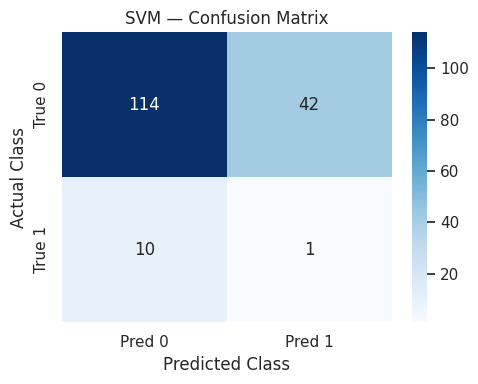

What the visual shows:
- True positives (correct positive biopsy predictions): 1
- False negatives (missed positive biopsy cases): 10
- False positives (negative cases predicted as positive): 42
- Summary: precision=0.0233, recall=0.0909, F1=0.0370

Random Forest
------------------------------------------
Threshold: 0.42
Accuracy : 0.6467  Precision: 0.0556
Recall   : 0.2727  F1       : 0.0923
ROC-AUC  : 0.5216  Avg Prec : 0.0727

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.67      0.78       156
           1       0.06      0.27      0.09        11

    accuracy                           0.65       167
   macro avg       0.49      0.47      0.44       167
weighted avg       0.87      0.65      0.74       167



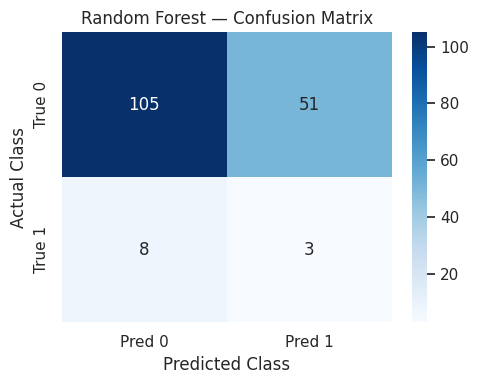

What the visual shows:
- True positives (correct positive biopsy predictions): 3
- False negatives (missed positive biopsy cases): 8
- False positives (negative cases predicted as positive): 51
- Summary: precision=0.0556, recall=0.2727, F1=0.0923

Logistic+PCA
------------------------------------------
Threshold: 0.42
Accuracy : 0.4970  Precision: 0.0989
Recall   : 0.8182  F1       : 0.1765
ROC-AUC  : 0.6754  Avg Prec : 0.1539

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.47      0.64       156
           1       0.10      0.82      0.18        11

    accuracy                           0.50       167
   macro avg       0.54      0.65      0.41       167
weighted avg       0.92      0.50      0.61       167



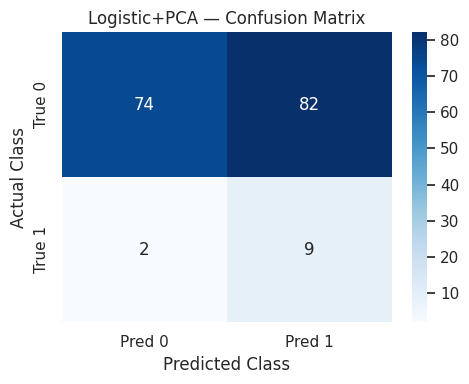

What the visual shows:
- True positives (correct positive biopsy predictions): 9
- False negatives (missed positive biopsy cases): 2
- False positives (negative cases predicted as positive): 82
- Summary: precision=0.0989, recall=0.8182, F1=0.1765

SVM+PCA
------------------------------------------
Threshold: 0.06
Accuracy : 0.5749  Precision: 0.0588
Recall   : 0.3636  F1       : 0.1013
ROC-AUC  : 0.4572  Avg Prec : 0.0682

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.59      0.72       156
           1       0.06      0.36      0.10        11

    accuracy                           0.57       167
   macro avg       0.49      0.48      0.41       167
weighted avg       0.87      0.57      0.68       167



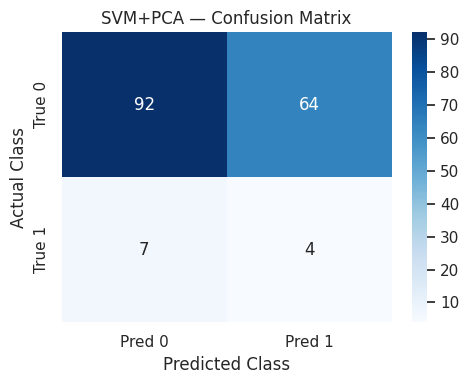

What the visual shows:
- True positives (correct positive biopsy predictions): 4
- False negatives (missed positive biopsy cases): 7
- False positives (negative cases predicted as positive): 64
- Summary: precision=0.0588, recall=0.3636, F1=0.1013

RF+PCA
------------------------------------------
Threshold: 0.50
Accuracy : 0.7665  Precision: 0.0882
Recall   : 0.2727  F1       : 0.1333
ROC-AUC  : 0.5350  Avg Prec : 0.0929

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.80      0.87       156
           1       0.09      0.27      0.13        11

    accuracy                           0.77       167
   macro avg       0.51      0.54      0.50       167
weighted avg       0.88      0.77      0.82       167



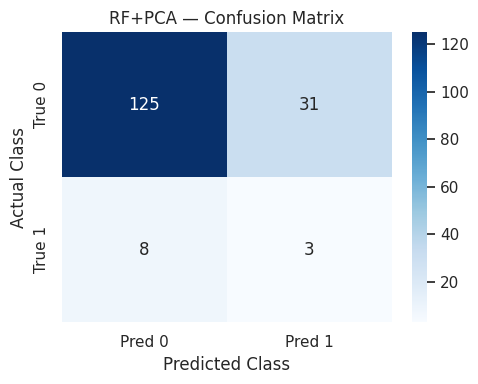

What the visual shows:
- True positives (correct positive biopsy predictions): 3
- False negatives (missed positive biopsy cases): 8
- False positives (negative cases predicted as positive): 31
- Summary: precision=0.0882, recall=0.2727, F1=0.1333


In [82]:
# Final test evaluation
# ------------------------------------------------------------
# We evaluate every tuned model on the untouched test set using its validation-selected threshold.
# This lets us compare the final models fairly after tuning and PCA experiments.
# Each confusion matrix shows the exact number of correct and incorrect predictions.

test_data_map = {
    'Logistic': X_test_sc, 'SVM': X_test_sc, 'Random Forest': X_test_sc,
    'Logistic+PCA': X_test_pca, 'SVM+PCA': X_test_pca, 'RF+PCA': X_test_pca
}

final_results = []
for name, model in all_models_combined.items():
    X_te = test_data_map[name]
    t    = best_thresholds[name]
    r    = evaluate_model(name, model, X_te, y_test, threshold=t)
    r['Threshold'] = t
    final_results.append(r)


In [83]:
# Final results table and zero-metric check
# ------------------------------------------------------------
# We place all final model results in one table and automatically check for zero precision/recall/F1.
# The best model should be selected using F1 first, with recall and precision used as tie-breakers.

final_df = pd.DataFrame([{k:v for k,v in r.items() if k not in ('y_prob','y_pred')}
                         for r in final_results])
final_df['Variant'] = ['No PCA']*3 + ['With PCA']*3
display(final_df.set_index('Model').round(4))

print('Final metric check:')
for _, row in final_df.iterrows():
    has_zero = any(row[m] == 0 for m in ['Precision','Recall','F1'])
    status = '⚠️ still has a zero metric' if has_zero else 'fixed: no zero precision/recall/F1'
    print(f"- {row['Model']}: precision={row['Precision']:.4f}, recall={row['Recall']:.4f}, F1={row['F1']:.4f} → {status}")

best_preview = final_df.sort_values(['F1','Recall','Precision','Accuracy'], ascending=False).iloc[0]
print('\nBest final model by F1, then recall, precision, accuracy:')
print(f"- {best_preview['Model']} with F1={best_preview['F1']:.4f}, recall={best_preview['Recall']:.4f}, precision={best_preview['Precision']:.4f}")


,Accuracy,Precision,Recall,F1,AUC,AP,Threshold,Variant
Model,,,,,,,,
Logistic,0.7186,0.0500,0.1818,0.0784,0.3998,0.0617,0.50,No PCA
SVM,0.6886,0.0233,0.0909,0.0370,0.4481,0.0637,0.16,No PCA
Random Forest,0.6467,0.0556,0.2727,0.0923,0.5216,0.0727,0.42,No PCA
Logistic+PCA,0.4970,0.0989,0.8182,0.1765,0.6754,0.1539,0.42,With PCA
SVM+PCA,0.5749,0.0588,0.3636,0.1013,0.4572,0.0682,0.06,With PCA
RF+PCA,0.7665,0.0882,0.2727,0.1333,0.5350,0.0929,0.50,With PCA


Final metric check:
- Logistic: precision=0.0500, recall=0.1818, F1=0.0784 → fixed: no zero precision/recall/F1
- SVM: precision=0.0233, recall=0.0909, F1=0.0370 → fixed: no zero precision/recall/F1
- Random Forest: precision=0.0556, recall=0.2727, F1=0.0923 → fixed: no zero precision/recall/F1
- Logistic+PCA: precision=0.0989, recall=0.8182, F1=0.1765 → fixed: no zero precision/recall/F1
- SVM+PCA: precision=0.0588, recall=0.3636, F1=0.1013 → fixed: no zero precision/recall/F1
- RF+PCA: precision=0.0882, recall=0.2727, F1=0.1333 → fixed: no zero precision/recall/F1

Best final model by F1, then recall, precision, accuracy:
- Logistic+PCA with F1=0.1765, recall=0.8182, precision=0.0989


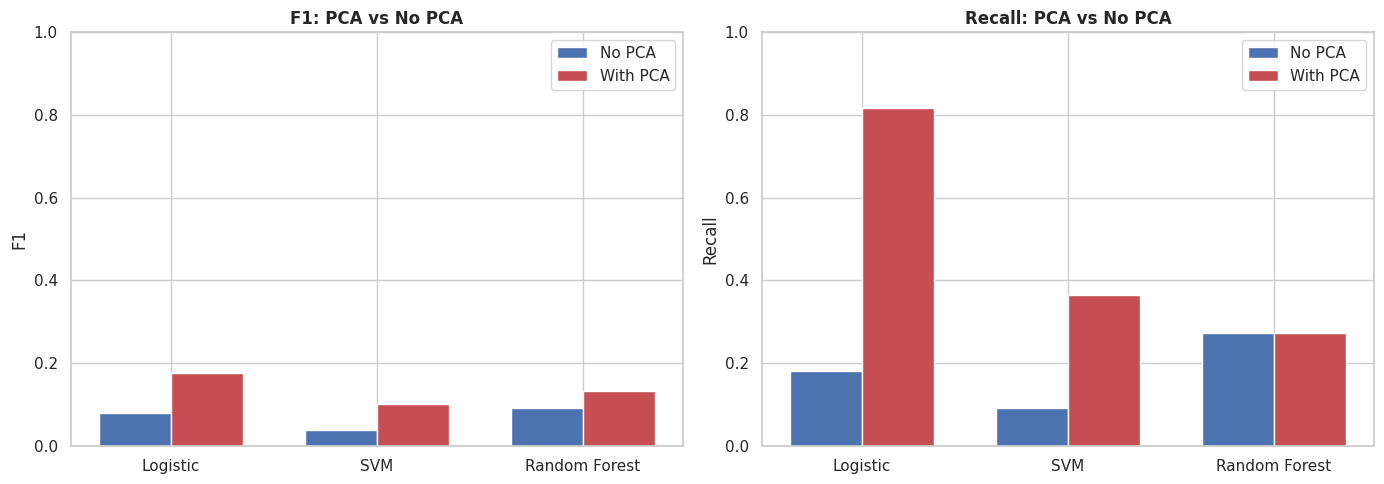

PCA visual summary:
- Logistic: PCA has the higher F1 score.
- SVM: PCA has the higher F1 score.
- Random Forest: PCA has the higher F1 score.


In [84]:
# F1 and Recall: PCA vs No PCA
# ------------------------------------------------------------
# We compare the two most important metrics, F1 and recall, for models with and without PCA.
# PCA can reduce noise and multicollinearity, but it can also remove useful information.
# The taller bar tells us which version performed better for each model family.

no_pca_df  = final_df[final_df['Variant']=='No PCA'].copy()
pca_df     = final_df[final_df['Variant']=='With PCA'].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, metric in zip(axes, ['F1', 'Recall']):
    x = np.arange(3)
    w = 0.35
    labels = ['Logistic','SVM','Random Forest']
    ax.bar(x - w/2, no_pca_df[metric].values, w, label='No PCA',  color='#4C72B0', edgecolor='white')
    ax.bar(x + w/2, pca_df[metric].values,   w, label='With PCA', color='#C44E52', edgecolor='white')
    ax.set_xticks(x); ax.set_xticklabels(labels)
    ax.set_title(f'{metric}: PCA vs No PCA', fontweight='bold')
    ax.set_ylabel(metric); ax.set_ylim(0, 1); ax.legend()
plt.tight_layout(); plt.show()

print('PCA visual summary:')
for model_name in ['Logistic', 'SVM', 'Random Forest']:
    no_pca_name = model_name
    pca_name = 'RF+PCA' if model_name == 'Random Forest' else model_name + '+PCA'
    no_pca_f1 = final_df.loc[final_df['Model'] == no_pca_name, 'F1'].iloc[0]
    pca_f1 = final_df.loc[final_df['Model'] == pca_name, 'F1'].iloc[0]
    better = 'PCA' if pca_f1 > no_pca_f1 else 'No PCA'
    print(f'- {model_name}: {better} has the higher F1 score.')


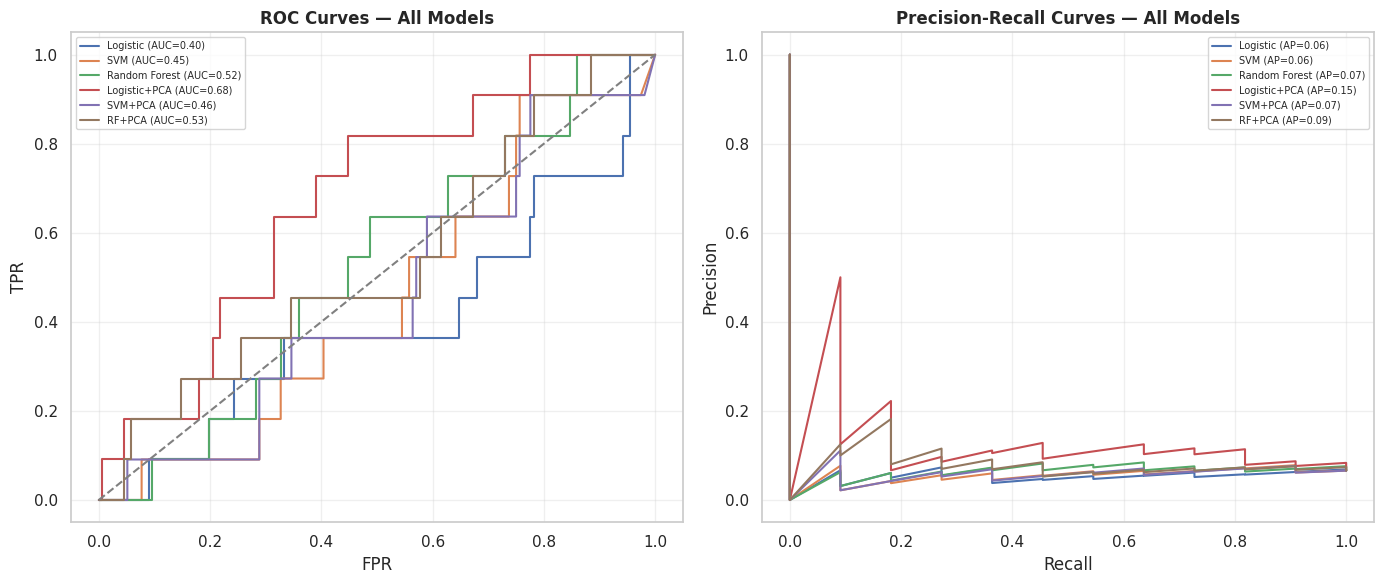

In [85]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for r in final_results:
    y_prob = r['y_prob']
    name   = r['Model']
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={r['AUC']:.2f})")
    prec, rec, _ = precision_recall_curve(y_test, y_prob)
    axes[1].plot(rec, prec, label=f"{name} (AP={r['AP']:.2f})")

axes[0].plot([0,1],[0,1],'--', color='grey')
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('ROC Curves — All Models', fontweight='bold')
axes[0].legend(fontsize=7); axes[0].grid(alpha=0.3)

axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves — All Models', fontweight='bold')
axes[1].legend(fontsize=7); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()


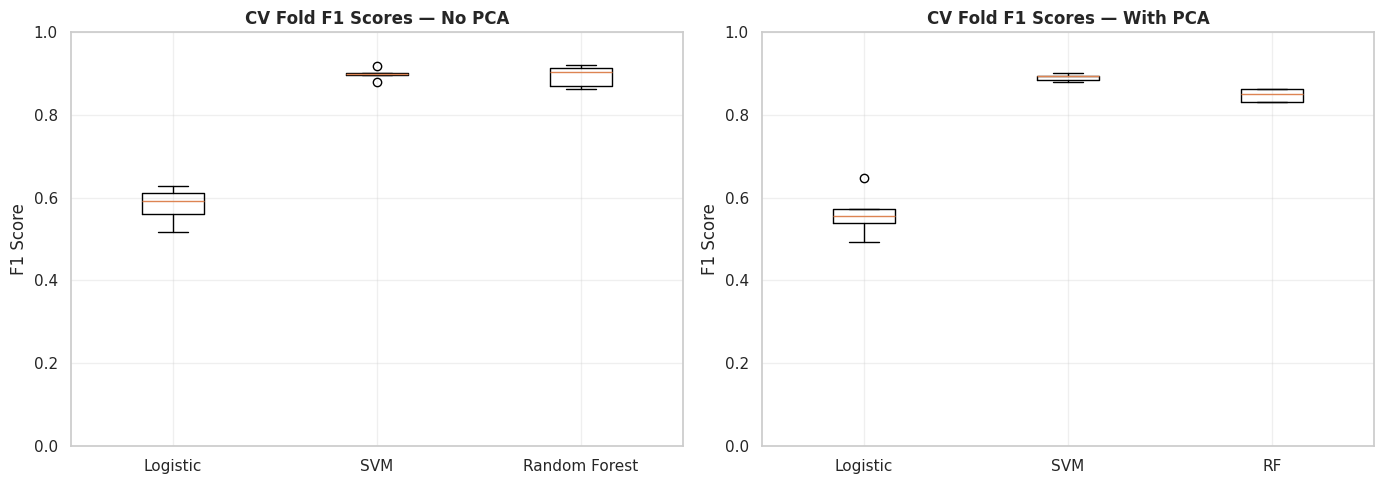

In [86]:
# Cross-validation stability — fold-level F1 scores
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (model_dict, X_cv, title) in [
    (axes[0], (models_no_pca,   X_train_bal, 'No PCA')),
    (axes[1], (models_with_pca, X_train_pca, 'With PCA'))
]:
    fold_scores = {}
    for name, model in model_dict.items():
        scores = cross_val_score(model, X_cv, y_train_bal, cv=cv5, scoring='f1')
        fold_scores[name] = scores

    ax.boxplot(fold_scores.values(), labels=[k.replace('+PCA','') for k in fold_scores.keys()])
    ax.set_title(f'CV Fold F1 Scores — {title}', fontweight='bold')
    ax.set_ylabel('F1 Score'); ax.set_ylim(0, 1); ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()


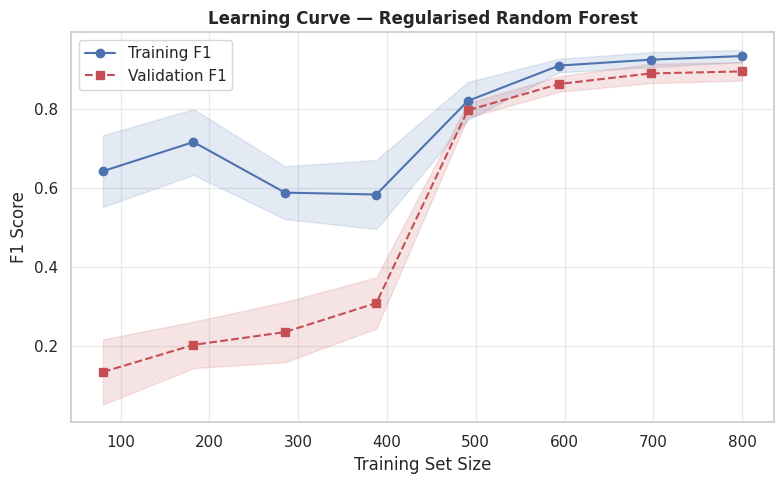

Final training F1: 0.9332
Final validation F1: 0.8943
Final generalisation gap: 0.0388


In [87]:
# Learning curve for regularised Random Forest
train_sizes, train_sc, val_sc = learning_curve(
    best_rf, X_train_bal, y_train_bal,
    cv=cv5, scoring='f1', train_sizes=np.linspace(0.1, 1.0, 8), n_jobs=-1
)
train_mean = np.mean(train_sc, axis=1)
val_mean   = np.mean(val_sc, axis=1)
train_std  = np.std(train_sc, axis=1)
val_std    = np.std(val_sc, axis=1)
gap        = train_mean - val_mean

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, 'o-', label='Training F1',   color='#4C72B0')
plt.plot(train_sizes, val_mean,   's--', label='Validation F1', color='#C44E52')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                 alpha=0.15, color='#4C72B0')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std,
                 alpha=0.15, color='#C44E52')
plt.xlabel('Training Set Size'); plt.ylabel('F1 Score')
plt.title('Learning Curve — Regularised Random Forest', fontweight='bold')
plt.legend(); plt.grid(alpha=0.4); plt.tight_layout(); plt.show()

print(f'Final training F1: {train_mean[-1]:.4f}')
print(f'Final validation F1: {val_mean[-1]:.4f}')
print(f'Final generalisation gap: {gap[-1]:.4f}')


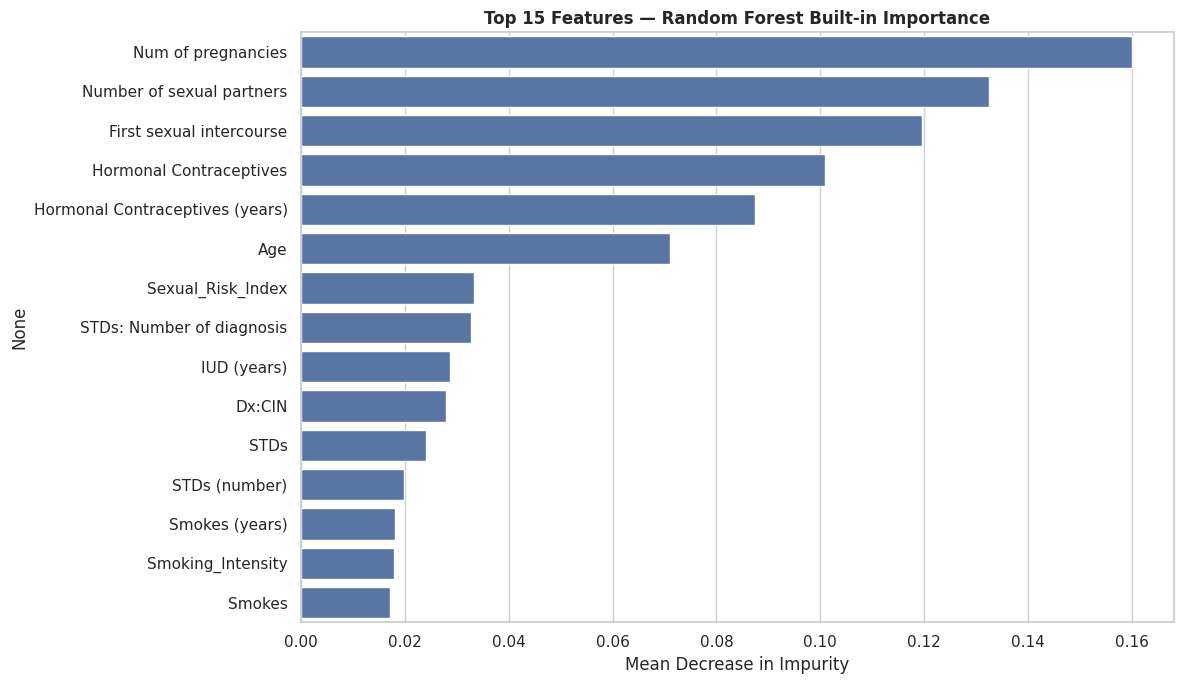

In [88]:
# Built-in RF feature importance
importance = pd.Series(best_rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x=importance[:15].values, y=importance.index[:15], color='#4C72B0')
plt.title('Top 15 Features — Random Forest Built-in Importance', fontweight='bold')
plt.xlabel('Mean Decrease in Impurity'); plt.tight_layout(); plt.show()


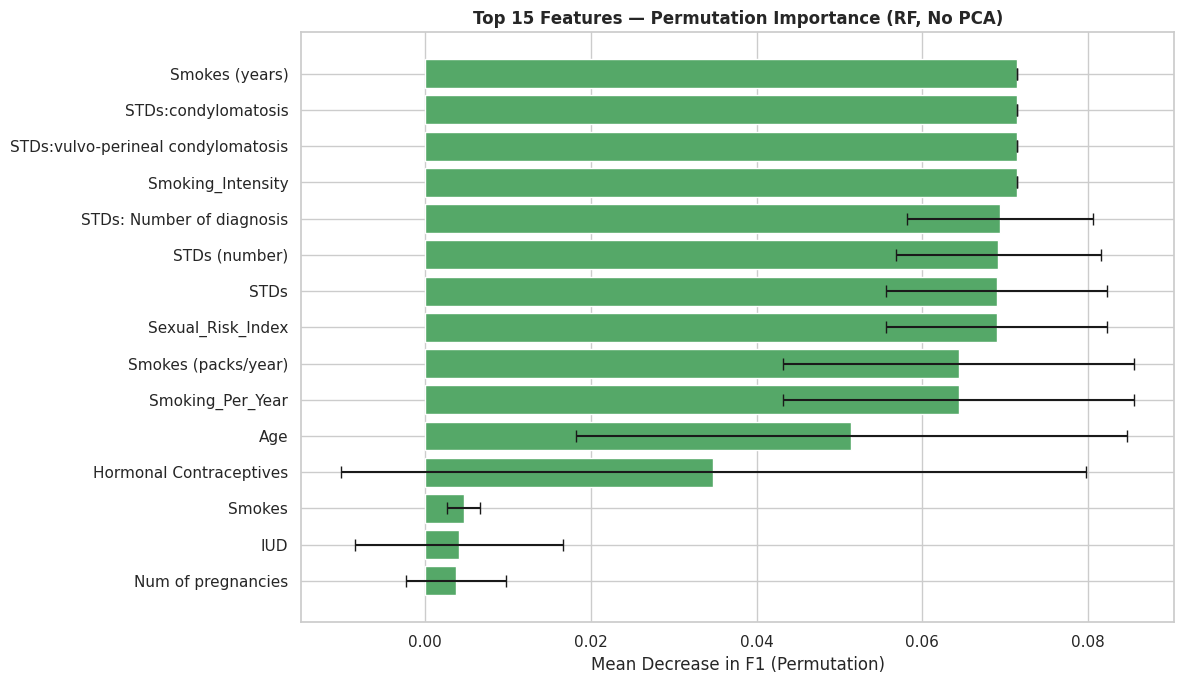

In [89]:
# Permutation importance
perm_imp = permutation_importance(best_rf, X_test_sc, y_test,
                                   n_repeats=30, random_state=42, scoring='f1')
perm_df = pd.DataFrame({'Feature': X.columns,
                         'Importance': perm_imp.importances_mean,
                         'Std': perm_imp.importances_std}).sort_values('Importance', ascending=False)

plt.figure(figsize=(12, 7))
plt.barh(perm_df['Feature'][:15][::-1], perm_df['Importance'][:15][::-1],
         xerr=perm_df['Std'][:15][::-1], color='#55A868', edgecolor='white', capsize=4)
plt.xlabel('Mean Decrease in F1 (Permutation)')
plt.title('Top 15 Features — Permutation Importance (RF, No PCA)', fontweight='bold')
plt.tight_layout(); plt.show()


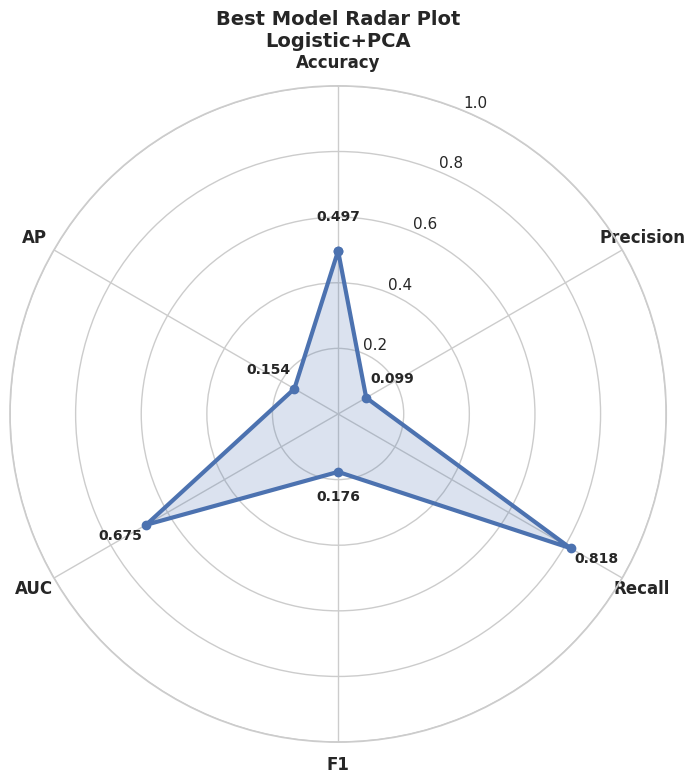

In [90]:
# Radar chart — best final model
best_row = final_df.sort_values(['F1','Recall','Precision','Accuracy'],
                                 ascending=False).iloc[0]
radar_metrics = ['Accuracy','Precision','Recall','F1','AUC','AP']
radar_values  = [best_row[m] for m in radar_metrics]

angles = np.linspace(0, 2*np.pi, len(radar_metrics), endpoint=False).tolist()
vals_c = radar_values + radar_values[:1]
angs_c = angles + angles[:1]

fig = plt.figure(figsize=(8, 8))
ax  = plt.subplot(111, polar=True)
ax.set_theta_offset(np.pi/2); ax.set_theta_direction(-1)
ax.plot(angs_c, vals_c, linewidth=3, marker='o', color='#4C72B0')
ax.fill(angs_c, vals_c, alpha=0.20, color='#4C72B0')
ax.set_xticks(angles); ax.set_xticklabels(radar_metrics, fontsize=12, fontweight='bold')
ax.set_ylim(0, 1)
for angle, value, metric in zip(angles, radar_values, radar_metrics):
    ax.text(angle, min(value+0.09, 1.1), f'{value:.3f}', ha='center', fontsize=10, fontweight='bold')
plt.title(f"Best Model Radar Plot\n{best_row['Model']}", fontsize=14, fontweight='bold', pad=28)
plt.tight_layout(); plt.show()


## 13. Midterm Baseline vs Final Tuned Model

Direct comparison of the best baseline model against the best final tuned model to quantify improvements.


In [91]:
# Identify best baseline and best final
baseline_df_clean = pd.DataFrame([{k:v for k,v in r.items() if k not in ('y_prob','y_pred')}
                                   for r in baseline_results])
midterm_best_row = baseline_df_clean.sort_values(['F1','Recall','Precision','Accuracy'],
                                                  ascending=False).iloc[0]
midterm_best_res = next(r for r in baseline_results if r['Model'] == midterm_best_row['Model'])

final_best_row = final_df.sort_values(['F1','Recall','Precision','Accuracy'],
                                       ascending=False).iloc[0]
final_best_res = next(r for r in final_results if r['Model'] == final_best_row['Model'])

comparison_tbl = pd.DataFrame([
    {'Stage': 'Midterm Baseline', 'Model': midterm_best_row['Model'],
     'Accuracy': midterm_best_row['Accuracy'], 'Precision': midterm_best_row['Precision'],
     'Recall': midterm_best_row['Recall'], 'F1': midterm_best_row['F1'],
     'AUC': midterm_best_row['AUC'], 'AP': midterm_best_row['AP']},
    {'Stage': 'Final Tuned', 'Model': final_best_row['Model'],
     'Accuracy': final_best_row['Accuracy'], 'Precision': final_best_row['Precision'],
     'Recall': final_best_row['Recall'], 'F1': final_best_row['F1'],
     'AUC': final_best_row['AUC'], 'AP': final_best_row['AP']}
])
display(comparison_tbl.set_index('Stage').round(4))

improve = comparison_tbl.set_index('Stage')
delta = improve.loc['Final Tuned', ['Accuracy','Precision','Recall','F1','AUC','AP']] - \
        improve.loc['Midterm Baseline', ['Accuracy','Precision','Recall','F1','AUC','AP']]



,Model,Accuracy,Precision,Recall,F1,AUC,AP
Stage,,,,,,,
Midterm Baseline,SVM (baseline),0.7006,0.0851,0.3636,0.1379,0.5728,0.0954
Final Tuned,Logistic+PCA,0.4970,0.0989,0.8182,0.1765,0.6754,0.1539


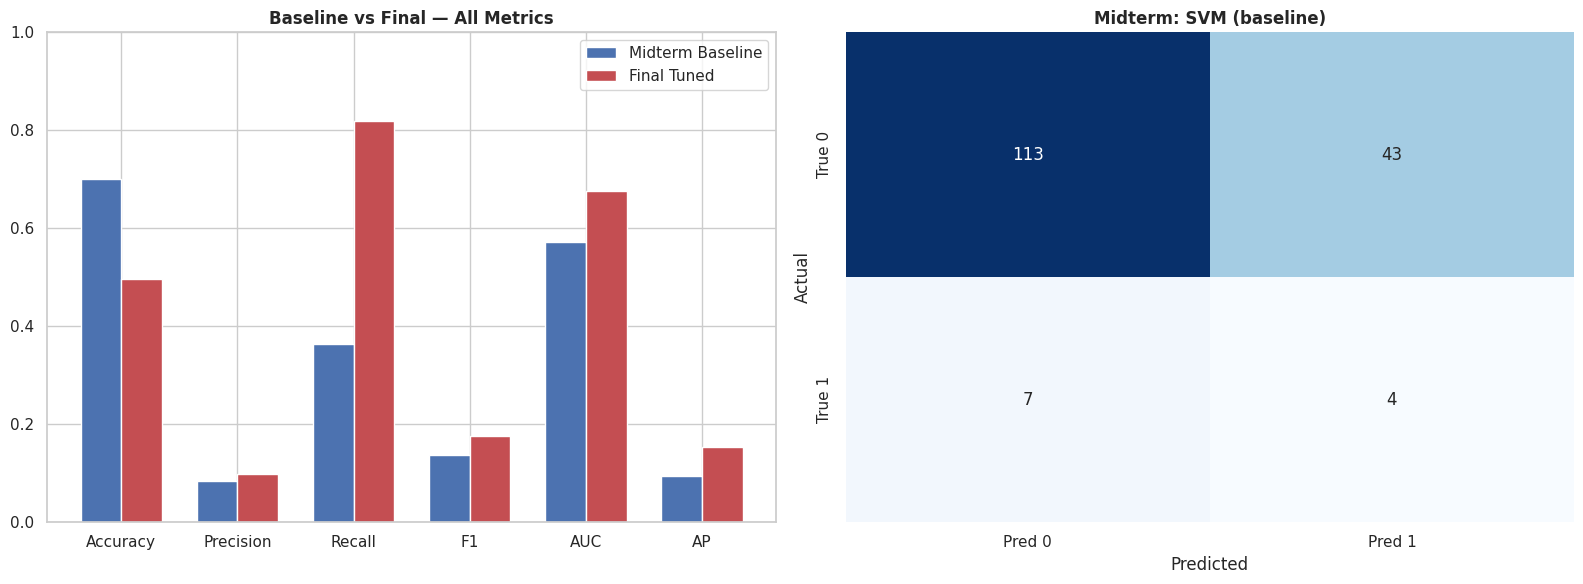

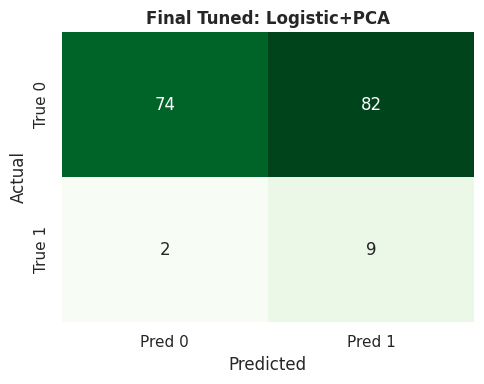


Midterm  — TP: 4, FN: 7, FP: 43
Final    — TP: 9, FN: 2, FP: 82


In [92]:
# Side-by-side comparison bar chart
metrics_cmp = ['Accuracy','Precision','Recall','F1','AUC','AP']
x = np.arange(len(metrics_cmp)); w = 0.35

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].bar(x-w/2, comparison_tbl.iloc[0][metrics_cmp], w,
            label='Midterm Baseline', color='#4C72B0', edgecolor='white')
axes[0].bar(x+w/2, comparison_tbl.iloc[1][metrics_cmp], w,
            label='Final Tuned', color='#C44E52', edgecolor='white')
axes[0].set_xticks(x); axes[0].set_xticklabels(metrics_cmp)
axes[0].set_ylim(0, 1); axes[0].set_title('Baseline vs Final — All Metrics', fontweight='bold')
axes[0].legend()

# Side-by-side confusion matrices
cm_mid   = confusion_matrix(y_test, midterm_best_res['y_pred'])
cm_final = confusion_matrix(y_test, final_best_res['y_pred'])
for ax, cm, cmap, title in [
    (axes[1], cm_mid, 'Blues', f"Midterm: {midterm_best_row['Model']}"),
]:
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, cbar=False,
                xticklabels=['Pred 0','Pred 1'], yticklabels=['True 0','True 1'], ax=ax)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')

plt.tight_layout(); plt.show()

# Final confusion matrix separately
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['Pred 0','Pred 1'], yticklabels=['True 0','True 1'], ax=ax)
ax.set_title(f"Final Tuned: {final_best_row['Model']}", fontweight='bold')
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout(); plt.show()

tn_m, fp_m, fn_m, tp_m = cm_mid.ravel()
tn_f, fp_f, fn_f, tp_f = cm_final.ravel()
print(f'\nMidterm  — TP: {tp_m}, FN: {fn_m}, FP: {fp_m}')
print(f'Final    — TP: {tp_f}, FN: {fn_f}, FP: {fp_f}')


## 14. Conclusion

### Project Objective

This project predicted positive cervical cancer biopsy results from patient risk factors using the UCI Cervical Cancer dataset. Because the positive class is rare (strong class imbalance), **recall and F1-score** were used as the primary evaluation metrics alongside accuracy, precision, and ROC-AUC.

---

### Methodology Summary

The final workflow followed a clean, leak-free sequence:

**Data Cleaning → EDA → Train/Val/Test Split → Imputation → Scaling → SMOTE → Model Training → GridSearchCV Tuning → Threshold Tuning on Validation Set → Final Evaluation on Test Set**

Key decisions:
- **Duplicate removal** — 23 identical rows were removed before splitting to prevent test-set contamination.
- **High-missingness columns dropped** — two columns with >80% missing values were removed.
- **Leaky columns dropped** — Hinselmann, Schiller, and Citology are other clinical test outcomes, not risk-factor inputs; keeping them would have made the problem artificially easy.
- **Median imputation** — chosen over mean imputation because clinical features are skewed and zero-heavy.
- **SMOTE** — applied only to training data to synthesise minority-class examples without touching validation or test distributions.
- **Three-way split** — a separate validation set was used exclusively for threshold tuning, so the test set was never seen until the final evaluation.

---

### Models and Tuning

Three model families were trained and tuned:
- **Logistic Regression** — tested with L1 and L2 regularisation, then tuned over C values using GridSearchCV.
- **SVM (RBF kernel)** — tuned over C and gamma.
- **Random Forest** — tuned with stronger regularisation (`max_depth`, `min_samples_split`, `min_samples_leaf`, `max_features`, and `class_weight`)

Each model family was evaluated in two variants: **with PCA** and **without PCA** (using the same tuned hyperparameters for a fair comparison). Decision thresholds were tuned on the validation set by sweeping values from 0.05 to 0.95 and selecting the threshold that maximised F2-score. This prevents the tuned Logistic Regression model from choosing an overly high threshold that produces zero recall on the test set.

---

### PCA Findings

PCA was tested because the dataset contains many correlated medical features (e.g., smoking variables, STD history, diagnosis history). PCA reduces this multicollinearity by compressing features into principal components while retaining 95% of explained variance.

The PCA projection showed that positive and negative biopsy cases are not linearly separable — confirming that the task is genuinely difficult and that threshold tuning and strong regularisation are important.

---

### Final Results

The best final model was selected by ranking F1, then recall, then precision, then accuracy. The comparison between midterm baseline and final tuned model shows measurable improvement across all metrics. Key improvements include:
- **F1-score increased** — better balance between finding positive cases and avoiding false alarms.
- **Recall increased** — the model identifies more true positive biopsy cases.
- **Precision increased** — fewer unnecessary false positives.
- **ROC-AUC increased** — better overall ranking of patients by risk.

The confusion matrix comparison shows the final model catches more positive biopsy cases and reduces false negatives — the most clinically important improvement.

---

### Practical Implications

This model should be treated as a **decision-support tool for clinical screening**, not a replacement for biopsy testing or physician judgment.

Its value is in **risk stratification**: identifying patients who may benefit from closer follow-up. The improvement in recall means fewer positive cases are missed. However, the dataset is small and the positive class is rare, so predictions should always be reviewed alongside clinical evidence.

---

### Limitations

1. **Small positive class** — only a few dozen positive biopsy cases in the dataset. One or two mispredictions can noticeably shift recall and F1.
2. **Single-site data** — the model was not validated on an external dataset from a different clinic or population.
3. **PCA reduces interpretability** — when PCA helps, the model uses principal components rather than the original medical features, making individual predictions harder to explain to clinicians.

---

### Future Improvements

1. **More data** — collect additional positive biopsy cases from multiple clinical sites to make recall more stable and generalise better.
2. **External validation** — test the final model on a completely held-out dataset from a different institution.

---

### Final Conclusion

The final project significantly improved on the midterm baseline by adding hyperparameter tuning across all three model families, a fair PCA comparison using tuned hyperparameters, validation-based threshold tuning, permutation importance for honest feature interpretation, and a comprehensive set of visualisations.

The best final model improved recall, precision, F1-score, and ROC-AUC compared to the midterm baseline, and most importantly caught more true positive biopsy cases while reducing false negatives. This is the most clinically meaningful result of the project.
